In [3]:
!pip install pytorch-forecasting pytorch-lightning optuna --quiet

In [4]:
# ============================================================
# CELL 1 — UNIVERSAL IMPORTS (Colab-compatible, conflict-free)
# ============================================================

# ── Core data handling ────────────────────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import warnings
import json
import re
import os
import requests
from tqdm import tqdm

# ── Statistical analysis & econometrics ──────────────────────
from scipy import stats
from scipy.stats import jarque_bera, shapiro, spearmanr, pearsonr
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, grangercausalitytests
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.var_model import VAR
import statsmodels.api as sm

# ── Preprocessing & feature engineering ──────────────────────
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.feature_selection import mutual_info_regression, SelectKBest

# ── Gradient boosting models ──────────────────────────────────
import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import xgboost as xgb
from xgboost import XGBRegressor

# ── Deep learning (PyTorch) ───────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Temporal Fusion Transformer ───────────────────────────────
from pytorch_forecasting import (
    TemporalFusionTransformer,
    TimeSeriesDataSet,
    GroupNormalizer,
)
from pytorch_forecasting.metrics import QuantileLoss, SMAPE, MAE
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# ── Uncertainty quantification (no MAPIE — Colab-safe) ───────
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import QuantileRegressor

class ConformalRegressor:
    """
    Split conformal prediction wrapper.
    Wraps any sklearn-compatible regressor and produces
    calibrated prediction intervals with marginal coverage guarantee.
    Replaces MAPIE — identical methodology, zero extra dependencies.

    Usage:
        cr = ConformalRegressor(LGBMRegressor(), coverage=0.80)
        cr.fit(X_train, y_train, X_cal, y_cal)
        y_hat, y_low, y_high = cr.predict(X_test)
    """
    def __init__(self, estimator, coverage: float = 0.80):
        self.estimator = estimator
        self.coverage  = coverage
        self.q_        = None

    def fit(self, X_train, y_train, X_cal, y_cal):
        self.estimator.fit(X_train, y_train)
        residuals = np.abs(y_cal - self.estimator.predict(X_cal))
        alpha     = 1 - self.coverage
        level     = np.ceil((1 - alpha) * (len(residuals) + 1)) / len(residuals)
        self.q_   = np.quantile(residuals, min(level, 1.0))
        return self

    def predict(self, X):
        if self.q_ is None:
            raise RuntimeError("Call .fit() before .predict()")
        y_hat = self.estimator.predict(X)
        return y_hat, y_hat - self.q_, y_hat + self.q_

print("✓ ConformalRegressor ready (split conformal, no MAPIE required)")

# ── Hyperparameter optimisation ───────────────────────────────
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Model evaluation & statistical tests ─────────────────────
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

# ── Interpretability (shap optional — Colab numpy conflict) ──
try:
    import shap
    SHAP_AVAILABLE = True
    print("✓ shap loaded")
except ImportError:
    shap            = None
    SHAP_AVAILABLE  = False
    print("⚠ shap unavailable — using LightGBM native feature importance instead")
    print("  (This is fully sufficient for publication-level feature attribution)")

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Utilities ─────────────────────────────────────────────────
from itertools import product
from typing import Dict, List, Optional, Tuple, Union
import logging

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

# ── Reproducibility seed ──────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
pl.seed_everything(SEED, workers=True)

# ── Summary ───────────────────────────────────────────────────
print("\n✓ All imports loaded successfully.")
print(f"  PyTorch     : {torch.__version__}")
print(f"  LightGBM    : {lgb.__version__}")
print(f"  XGBoost     : {xgb.__version__}")
print(f"  pandas      : {pd.__version__}")
print(f"  numpy       : {np.__version__}")
print(f"  SHAP        : {'available' if SHAP_AVAILABLE else 'skipped (numpy conflict)'}")
print(f"  Conformal   : ConformalRegressor (built-in)")

✓ ConformalRegressor ready (split conformal, no MAPIE required)
⚠ shap unavailable — using LightGBM native feature importance instead
  (This is fully sufficient for publication-level feature attribution)


INFO:lightning_fabric.utilities.seed:Seed set to 42



✓ All imports loaded successfully.
  PyTorch     : 2.10.0+cpu
  LightGBM    : 4.6.0
  XGBoost     : 3.2.0
  pandas      : 2.2.2
  numpy       : 2.4.4
  SHAP        : skipped (numpy conflict)
  Conformal   : ConformalRegressor (built-in)


In [5]:


# ============================================================
# CELL 2 — PROJECT CONFIG, PATHS & DATA DICTIONARY
# ============================================================

# ── Project paths ─────────────────────────────────────────────
BASE_DIR   = Path("karnataka_spice_forecast")
RAW_DIR    = BASE_DIR / "data" / "raw"
PROC_DIR   = BASE_DIR / "data" / "processed"
FEAT_DIR   = BASE_DIR / "data" / "features"
MODEL_DIR  = BASE_DIR / "models"
OUT_DIR    = BASE_DIR / "outputs"

for d in [RAW_DIR, PROC_DIR, FEAT_DIR, MODEL_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Project constants ─────────────────────────────────────────
CROPS        = ["vanilla", "arecanut"]
DISTRICTS    = ["Kodagu", "Shivamogga", "Uttara Kannada", "Chikkamagaluru", "Udupi"]
TRAIN_END    = "2019-12-31"
VAL_END      = "2021-12-31"
TEST_START   = "2022-01-01"
HORIZON      = 6        # forecast horizon in months
CONF_LEVEL   = 0.80     # conformal prediction coverage target
QUANTILES    = [0.10, 0.25, 0.50, 0.75, 0.90]   # for TFT quantile loss


# ============================================================
# DATA DICTIONARY
# One dict per source table / feature set.
# Each entry: column name → {dtype, unit, source, description}
# ============================================================

DATA_DICT: Dict[str, Dict] = {}

# ────────────────────────────────────────────────────────────
# TABLE 1 — raw_mandi_prices
# Source: AGMARKNET / CEDA Ashoka mandi portal
# Grain: district × commodity × date (daily)
# ────────────────────────────────────────────────────────────
DATA_DICT["raw_mandi_prices"] = {
    "date": {
        "dtype": "datetime64[ns]",
        "unit": "daily",
        "source": "AGMARKNET",
        "description": "Trade date on which prices were recorded at the mandi",
        "nullable": False,
    },
    "district": {
        "dtype": "str",
        "unit": "categorical",
        "source": "AGMARKNET",
        "description": "Karnataka district name (Census 2011 boundary). One of: Kodagu, Shivamogga, Uttara Kannada, Chikkamagaluru, Udupi",
        "nullable": False,
    },
    "mandi_name": {
        "dtype": "str",
        "unit": "categorical",
        "source": "AGMARKNET",
        "description": "Name of the Agricultural Produce Market Committee (APMC) regulated mandi",
        "nullable": False,
    },
    "commodity": {
        "dtype": "str",
        "unit": "categorical",
        "source": "AGMARKNET",
        "description": "Crop name. One of: vanilla, arecanut",
        "nullable": False,
    },
    "variety": {
        "dtype": "str",
        "unit": "categorical",
        "source": "AGMARKNET",
        "description": "Sub-variety or grade (e.g. cured vanilla, supari bold, supari small)",
        "nullable": True,
    },
    "price_min": {
        "dtype": "float64",
        "unit": "INR per quintal",
        "source": "AGMARKNET",
        "description": "Lowest transaction price recorded at the mandi on that date",
        "nullable": True,
    },
    "price_max": {
        "dtype": "float64",
        "unit": "INR per quintal",
        "source": "AGMARKNET",
        "description": "Highest transaction price recorded at the mandi on that date",
        "nullable": True,
    },
    "price_modal": {
        "dtype": "float64",
        "unit": "INR per quintal",
        "source": "AGMARKNET",
        "description": "Modal (most frequent) price — the primary target variable. Used as the official representative wholesale price",
        "nullable": False,
        "role": "TARGET",
    },
    "arrivals_qty": {
        "dtype": "float64",
        "unit": "quintals",
        "source": "AGMARKNET",
        "description": "Total quantity of produce arriving at the mandi on that date. Proxy for local supply volume",
        "nullable": True,
    },
}

# ────────────────────────────────────────────────────────────
# TABLE 2 — raw_production
# Source: DASD (Directorate of Arecanut & Spices Development)
#         + Karnataka Dept of Horticulture via data.gov.in
# Grain: state/district × commodity × crop year (annual)
# ────────────────────────────────────────────────────────────
DATA_DICT["raw_production"] = {
    "crop_year": {
        "dtype": "str",
        "unit": "annual (kharif year, e.g. '2021-22')",
        "source": "DASD",
        "description": "Indian agricultural crop year (April–March). Arecanut is a perennial crop; vanilla harvest season is December–April",
        "nullable": False,
    },
    "state": {
        "dtype": "str",
        "unit": "categorical",
        "source": "DASD",
        "description": "Indian state name. Primarily Karnataka in this project",
        "nullable": False,
    },
    "district": {
        "dtype": "str",
        "unit": "categorical",
        "source": "DASD",
        "description": "District-level disaggregation where available (not always present in DASD releases)",
        "nullable": True,
    },
    "commodity": {
        "dtype": "str",
        "unit": "categorical",
        "source": "DASD",
        "description": "Crop name: vanilla or arecanut",
        "nullable": False,
    },
    "area_ha": {
        "dtype": "float64",
        "unit": "hectares",
        "source": "DASD",
        "description": "Total area under cultivation for that crop in that year. Lagged 3–5 years creates supply pipeline feature",
        "nullable": True,
    },
    "production_tonnes": {
        "dtype": "float64",
        "unit": "metric tonnes",
        "source": "DASD",
        "description": "Total production volume harvested. Used to compute yield and as a supply-side feature",
        "nullable": True,
    },
    "productivity_kg_ha": {
        "dtype": "float64",
        "unit": "kg per hectare",
        "source": "DASD",
        "description": "Production per unit area (productivity = production / area). Signals quality/efficiency of that season",
        "nullable": True,
    },
}

# ────────────────────────────────────────────────────────────
# TABLE 3 — raw_export
# Source: Spices Board of India (indianspices.com/export)
# Grain: commodity × month (monthly)
# ────────────────────────────────────────────────────────────
DATA_DICT["raw_export"] = {
    "month": {
        "dtype": "datetime64[ns]",
        "unit": "monthly (first day of month)",
        "source": "Spices Board of India",
        "description": "Month of export record",
        "nullable": False,
    },
    "commodity": {
        "dtype": "str",
        "unit": "categorical",
        "source": "Spices Board of India",
        "description": "Spice commodity name (vanilla, cardamom, pepper, etc.)",
        "nullable": False,
    },
    "export_qty_tonnes": {
        "dtype": "float64",
        "unit": "metric tonnes",
        "source": "Spices Board of India",
        "description": "Total quantity exported from India in that month. Sharp drops indicate domestic supply constraints",
        "nullable": True,
    },
    "export_value_crore_inr": {
        "dtype": "float64",
        "unit": "INR crore (1 crore = 10 million)",
        "source": "Spices Board of India",
        "description": "Total FOB export value in INR crore",
        "nullable": True,
    },
    "unit_value_inr_kg": {
        "dtype": "float64",
        "unit": "INR per kg",
        "source": "Spices Board of India",
        "description": "Derived: export_value / export_qty. Serves as the international price signal received by Indian exporters",
        "nullable": True,
        "derived": True,
    },
    "destination_country": {
        "dtype": "str",
        "unit": "categorical",
        "source": "Spices Board of India",
        "description": "Destination country for that export shipment (available in country-wise breakdown)",
        "nullable": True,
    },
}

# ────────────────────────────────────────────────────────────
# TABLE 4 — raw_climate
# Source: IMD Gridded Rainfall Data + NOAA IOD Index
# Grain: district × month
# ────────────────────────────────────────────────────────────
DATA_DICT["raw_climate"] = {
    "month": {
        "dtype": "datetime64[ns]",
        "unit": "monthly",
        "source": "IMD / NOAA",
        "description": "Month of climate record",
        "nullable": False,
    },
    "district": {
        "dtype": "str",
        "unit": "categorical",
        "source": "IMD",
        "description": "Karnataka district. Gridded IMD data spatially joined to district centroid via inverse-distance weighting",
        "nullable": False,
    },
    "rainfall_mm": {
        "dtype": "float64",
        "unit": "millimetres",
        "source": "IMD 0.25° gridded",
        "description": "Monthly cumulative rainfall at district centroid. Extracted from IMD's 1mm × 1mm daily gridded product",
        "nullable": True,
    },
    "rainfall_anomaly_pct": {
        "dtype": "float64",
        "unit": "percent deviation from 1961–2010 normal",
        "source": "IMD",
        "description": "Departure of monthly rainfall from the long-run climatological normal. Key drought/flood signal",
        "nullable": True,
        "derived": True,
    },
    "monsoon_onset_day": {
        "dtype": "float64",
        "unit": "day of year (1–365)",
        "source": "IMD",
        "description": "Day of year on which the southwest monsoon onset was declared over Karnataka. Delayed onset → poor vanilla vine flowering",
        "nullable": True,
    },
    "max_temp_c": {
        "dtype": "float64",
        "unit": "degrees Celsius",
        "source": "IMD gridded temperature",
        "description": "Monthly mean of daily maximum temperature at district centroid",
        "nullable": True,
    },
    "iod_index": {
        "dtype": "float64",
        "unit": "dimensionless (SST anomaly °C)",
        "source": "NOAA/IOBW",
        "description": "Indian Ocean Dipole index (Dipole Mode Index). Positive IOD suppresses Karnataka monsoon. 6-month lagged version is the strongest climate predictor for vanilla flowering yield",
        "nullable": True,
    },
    "enso_oni": {
        "dtype": "float64",
        "unit": "dimensionless (°C)",
        "source": "NOAA CPC",
        "description": "Oceanic Niño Index (ONI). El Niño (positive) typically suppresses Indian monsoon. Secondary climate feature",
        "nullable": True,
    },
    "drought_index_spi3": {
        "dtype": "float64",
        "unit": "dimensionless (standard deviations)",
        "source": "Derived from IMD rainfall",
        "description": "3-month Standardised Precipitation Index. Negative values indicate drought stress on crops",
        "nullable": True,
        "derived": True,
    },
}

# ────────────────────────────────────────────────────────────
# TABLE 5 — raw_macro
# Source: RBI Handbook of Statistics on Indian Economy
#         + World Bank Pink Sheet
# Grain: monthly (national level)
# ────────────────────────────────────────────────────────────
DATA_DICT["raw_macro"] = {
    "month": {
        "dtype": "datetime64[ns]",
        "unit": "monthly",
        "source": "RBI / World Bank",
        "description": "Month of macroeconomic record",
        "nullable": False,
    },
    "wpi_spices": {
        "dtype": "float64",
        "unit": "index (base year varies by series)",
        "source": "RBI Handbook — WPI",
        "description": "Wholesale Price Index for the spices sub-group. Captures aggregate spice price inflation and is used as a deflator",
        "nullable": True,
    },
    "inr_usd_rate": {
        "dtype": "float64",
        "unit": "INR per 1 USD",
        "source": "RBI",
        "description": "Official exchange rate INR/USD monthly average. INR depreciation raises vanilla export unit value, creating a domestic price upward pull",
        "nullable": False,
    },
    "cpi_india": {
        "dtype": "float64",
        "unit": "index",
        "source": "RBI / MOSPI",
        "description": "All-India Consumer Price Index (combined). Used for real price deflation of mandi series",
        "nullable": True,
    },
    "vanilla_world_price_usd_kg": {
        "dtype": "float64",
        "unit": "USD per kg",
        "source": "World Bank Pink Sheet",
        "description": "International benchmark vanilla price in USD/kg. The most important external price signal — Madagascar supply shocks appear here first, then transmit to Karnataka mandi prices",
        "nullable": True,
    },
    "pepper_world_price_usd_tonne": {
        "dtype": "float64",
        "unit": "USD per metric tonne",
        "source": "World Bank Pink Sheet",
        "description": "International black pepper price. Acts as a substitute/complement commodity for Karnataka plantation farmers",
        "nullable": True,
    },
    "crude_oil_brent_usd": {
        "dtype": "float64",
        "unit": "USD per barrel",
        "source": "World Bank Pink Sheet",
        "description": "Brent crude price. Proxy for transport and input cost — fertiliser prices are correlated with crude. Also affects export container freight rates",
        "nullable": True,
    },
    "covid_shock": {
        "dtype": "int8",
        "unit": "binary (0/1)",
        "source": "Manually encoded",
        "description": "1 for months April 2020 – March 2022 (COVID-19 disruption period). Used as a structural break dummy in SARIMAX and as a categorical feature in ML models",
        "nullable": False,
        "derived": True,
    },
    "madagascar_shock": {
        "dtype": "int8",
        "unit": "binary (0/1)",
        "source": "Manually encoded",
        "description": "1 for months January 2022 – June 2023 (Madagascar cyclone-induced vanilla supply collapse). Enables models to separately identify global supply shock effects on Karnataka mandi prices",
        "nullable": False,
        "derived": True,
    },
}

# ────────────────────────────────────────────────────────────
# TABLE 6 — panel_features (the final ML feature matrix)
# Source: Derived / merged from all tables above
# Grain: district × commodity × month
# ────────────────────────────────────────────────────────────
DATA_DICT["panel_features"] = {
    # ── Identifiers ──
    "month": {
        "dtype": "datetime64[ns]",
        "unit": "monthly",
        "source": "Derived",
        "description": "Panel time index (first day of month)",
        "role": "INDEX",
    },
    "district": {
        "dtype": "str",
        "unit": "categorical",
        "source": "Derived",
        "description": "Karnataka district. Static covariate in TFT",
        "role": "STATIC_COVARIATE",
    },
    "commodity": {
        "dtype": "str",
        "unit": "categorical",
        "source": "Derived",
        "description": "Crop identifier. Static covariate in TFT",
        "role": "STATIC_COVARIATE",
    },
    "group_id": {
        "dtype": "str",
        "unit": "categorical",
        "source": "Derived",
        "description": "Unique panel unit key: district + '_' + commodity (e.g. 'Kodagu_vanilla')",
        "role": "GROUP_KEY",
        "derived": True,
    },
    "time_idx": {
        "dtype": "int64",
        "unit": "integer months since 2010-01-01",
        "source": "Derived",
        "description": "Integer time index required by pytorch-forecasting TimeSeriesDataSet",
        "role": "TIME_INDEX",
        "derived": True,
    },

    # ── Target variable ──
    "price_modal_inr_quintal": {
        "dtype": "float64",
        "unit": "INR per quintal (monthly average of daily modal prices)",
        "source": "AGMARKNET",
        "description": "PRIMARY TARGET. Monthly mean of daily mandi modal prices for the commodity in that district",
        "role": "TARGET",
    },
    "log_price": {
        "dtype": "float64",
        "unit": "log(INR per quintal)",
        "source": "Derived",
        "description": "Natural log of price_modal_inr_quintal. Used as modelling target to stabilise variance and reduce skewness of vanilla price distribution",
        "role": "TARGET_TRANSFORMED",
        "derived": True,
    },
    "real_price_2015_inr": {
        "dtype": "float64",
        "unit": "INR per quintal (2015 base)",
        "source": "Derived",
        "description": "Nominal price deflated by CPI index (base 2015). Used for long-run comparison across districts",
        "role": "SUPPLEMENTARY_TARGET",
        "derived": True,
    },

    # ── Lag features ──
    "price_lag_1m": {
        "dtype": "float64",
        "unit": "INR per quintal",
        "source": "Derived",
        "description": "Price one month prior. Strongest single predictor (AR(1) momentum)",
        "role": "FEATURE",
        "derived": True,
    },
    "price_lag_3m": {
        "dtype": "float64",
        "unit": "INR per quintal",
        "source": "Derived",
        "description": "Price three months prior. Captures quarterly price cycle in arecanut auction calendar",
        "role": "FEATURE",
        "derived": True,
    },
    "price_lag_6m": {
        "dtype": "float64",
        "unit": "INR per quintal",
        "source": "Derived",
        "description": "Price six months prior. Captures the harvest-to-market lag for vanilla (green → cured processing takes 4–6 months)",
        "role": "FEATURE",
        "derived": True,
    },
    "price_lag_12m": {
        "dtype": "float64",
        "unit": "INR per quintal",
        "source": "Derived",
        "description": "Price twelve months prior. Captures annual seasonal baseline",
        "role": "FEATURE",
        "derived": True,
    },

    # ── Rolling statistics ──
    "rolling_vol_3m": {
        "dtype": "float64",
        "unit": "INR per quintal (std dev)",
        "source": "Derived",
        "description": "3-month rolling standard deviation of price_modal. Measures short-term price uncertainty — high volatility periods are harder to forecast",
        "role": "FEATURE",
        "derived": True,
    },
    "rolling_mean_6m": {
        "dtype": "float64",
        "unit": "INR per quintal",
        "source": "Derived",
        "description": "6-month rolling mean. Smoothed trend signal; distance from rolling mean captures mean-reversion dynamics",
        "role": "FEATURE",
        "derived": True,
    },
    "momentum_3m": {
        "dtype": "float64",
        "unit": "percent",
        "source": "Derived",
        "description": "3-month price momentum: (price_t / price_{t-3}) - 1. Positive = upward price trend",
        "role": "FEATURE",
        "derived": True,
    },

    # ── Supply features ──
    "arrivals_lag_1m": {
        "dtype": "float64",
        "unit": "quintals",
        "source": "AGMARKNET",
        "description": "Total mandi arrivals (supply volume) from 1 month prior. Increased arrivals → downward price pressure",
        "role": "FEATURE",
    },
    "production_lag_1yr": {
        "dtype": "float64",
        "unit": "metric tonnes",
        "source": "DASD",
        "description": "District production from the prior crop year. Long-run supply baseline — vanilla production lags planting by 3 years",
        "role": "FEATURE",
    },
    "area_lag_3yr": {
        "dtype": "float64",
        "unit": "hectares",
        "source": "DASD",
        "description": "Area under cultivation 3 crop years prior. Leading indicator of future supply pipeline (planting decisions made 3–5 years before harvest for vanilla)",
        "role": "FEATURE",
    },

    # ── Export demand features ──
    "export_qty_lag_1m": {
        "dtype": "float64",
        "unit": "metric tonnes",
        "source": "Spices Board",
        "description": "National export quantity from 1 month prior. High export demand pulls domestic prices upward",
        "role": "FEATURE",
    },
    "export_unit_value_lag_1m": {
        "dtype": "float64",
        "unit": "INR per kg",
        "source": "Spices Board (derived)",
        "description": "Export unit value (₹/kg) from 1 month prior. Proxy for international price signal received by exporters",
        "role": "FEATURE",
        "derived": True,
    },
    "vanilla_world_price_lag_1m": {
        "dtype": "float64",
        "unit": "USD per kg",
        "source": "World Bank Pink Sheet",
        "description": "International vanilla benchmark price from 1 month prior. The leading external price signal that precedes Karnataka mandi movements",
        "role": "FEATURE",
    },

    # ── Climate features ──
    "iod_lag_6m": {
        "dtype": "float64",
        "unit": "dimensionless",
        "source": "NOAA (6-month lag applied)",
        "description": "Indian Ocean Dipole index lagged 6 months. Positive IOD → reduced Karnataka monsoon → poor vanilla flowering → future supply reduction → price rise. The mechanistically justified climate predictor",
        "role": "FEATURE",
    },
    "rainfall_anomaly_lag_6m": {
        "dtype": "float64",
        "unit": "percent",
        "source": "IMD (6-month lag applied)",
        "description": "District rainfall anomaly (% deviation from normal) lagged 6 months. Captures the biological lag from rainfall deficit to crop yield impact",
        "role": "FEATURE",
    },
    "spi3_lag_3m": {
        "dtype": "float64",
        "unit": "standard deviations",
        "source": "Derived from IMD (3-month lag)",
        "description": "3-month SPI drought index lagged 3 months. Negative SPI → drought stress on vines → yield reduction",
        "role": "FEATURE",
    },
    "monsoon_onset_anomaly": {
        "dtype": "float64",
        "unit": "days",
        "source": "IMD",
        "description": "Deviation of that year's monsoon onset date from the 1961–2010 normal onset date. Delayed onset correlates with reduced vanilla flowering in Kodagu",
        "role": "FEATURE",
    },

    # ── Macro features ──
    "inr_usd_lag_1m": {
        "dtype": "float64",
        "unit": "INR per USD",
        "source": "RBI",
        "description": "Exchange rate from 1 month prior. INR depreciation raises export realisation → upward mandi price pressure",
        "role": "FEATURE",
    },
    "crude_oil_lag_1m": {
        "dtype": "float64",
        "unit": "USD per barrel",
        "source": "World Bank Pink Sheet",
        "description": "Brent crude price lagged 1 month. Proxy for input cost (fertiliser, transport) and freight rate impacts on export competitiveness",
        "role": "FEATURE",
    },

    # ── Calendar / structural dummies ──
    "month_of_year": {
        "dtype": "int8",
        "unit": "1–12",
        "source": "Derived",
        "description": "Month number. Encodes seasonality — vanilla harvest November–April, arecanut Shivamogga auction peaks October–February",
        "role": "FEATURE",
    },
    "is_harvest_season": {
        "dtype": "int8",
        "unit": "binary (0/1)",
        "source": "Derived",
        "description": "1 if month falls within typical harvest/heavy-arrival season for that commodity (commodity-specific)",
        "role": "FEATURE",
        "derived": True,
    },
    "covid_shock": {
        "dtype": "int8",
        "unit": "binary (0/1)",
        "source": "Manually encoded",
        "description": "1 for April 2020 – March 2022. Structural break dummy for COVID-19 supply chain disruption",
        "role": "FEATURE",
    },
    "madagascar_shock": {
        "dtype": "int8",
        "unit": "binary (0/1)",
        "source": "Manually encoded",
        "description": "1 for January 2022 – June 2023. Marks the Madagascar vanilla supply collapse period (Cyclone Batsirai + Emnati). Enables shock-conditioned evaluation in O6",
        "role": "FEATURE",
    },
    "agro_zone": {
        "dtype": "str",
        "unit": "categorical (5 zones)",
        "source": "Karnataka Dept of Agriculture",
        "description": "Karnataka agro-climatic zone assignment. Zones: 'Hilly', 'Coastal', 'Malnad', 'Northern Dry', 'Southern Dry'. Static district-level covariate for zone-heterogeneity analysis (O5)",
        "role": "STATIC_COVARIATE",
    },
}


# ── Pretty print utility ──────────────────────────────────────
def print_dict(table_name: str, n_cols: int = 5) -> None:
    """Print a formatted summary of a data dictionary table."""
    cols = DATA_DICT[table_name]
    print(f"\n{'─'*70}")
    print(f"  TABLE: {table_name}   ({len(cols)} columns)")
    print(f"{'─'*70}")
    rows = []
    for col, meta in cols.items():
        rows.append({
            "column": col,
            "dtype": meta["dtype"],
            "unit": meta.get("unit", "—")[:35],
            "source": meta.get("source", "—")[:25],
            "role": meta.get("role", "FEATURE"),
        })
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))


# Print all tables
for table in DATA_DICT:
    print_dict(table)

print(f"\n\n{'='*70}")
print(f"  TOTAL tables   : {len(DATA_DICT)}")
print(f"  TOTAL columns  : {sum(len(v) for v in DATA_DICT.values())}")
print(f"  TARGET columns : {sum(1 for t in DATA_DICT.values() for c in t.values() if c.get('role','') in ('TARGET','TARGET_TRANSFORMED'))}")
print(f"  Feature cols   : {sum(1 for t in DATA_DICT.values() for c in t.values() if c.get('role','') == 'FEATURE')}")
print(f"{'='*70}")


──────────────────────────────────────────────────────────────────────
  TABLE: raw_mandi_prices   (9 columns)
──────────────────────────────────────────────────────────────────────
      column          dtype            unit    source    role
        date datetime64[ns]           daily AGMARKNET FEATURE
    district            str     categorical AGMARKNET FEATURE
  mandi_name            str     categorical AGMARKNET FEATURE
   commodity            str     categorical AGMARKNET FEATURE
     variety            str     categorical AGMARKNET FEATURE
   price_min        float64 INR per quintal AGMARKNET FEATURE
   price_max        float64 INR per quintal AGMARKNET FEATURE
 price_modal        float64 INR per quintal AGMARKNET  TARGET
arrivals_qty        float64        quintals AGMARKNET FEATURE

──────────────────────────────────────────────────────────────────────
  TABLE: raw_production   (7 columns)
──────────────────────────────────────────────────────────────────────
            colu

In [6]:
# ============================================================
# CELL 3 — DATA INGESTION
# Pulls from: AGMARKNET API, World Bank Pink Sheet,
#             NOAA IOD, RBI (manual CSV), Spices Board (manual CSV)
# Outputs: 5 raw DataFrames saved to RAW_DIR
# ============================================================

# ── 1. AGMARKNET — Mandi prices (vanilla + arecanut, Karnataka) ──────────────
# Official Government of India open data API
# Docs: https://data.gov.in/resource/variety-wise-daily-market-prices-data-commodity

AGMARKNET_API = "https://api.data.gov.in/resource/9ef84268-d588-465a-a308-a864a43d0070"
API_KEY       = "579b464db66ec23bdd000001cdd3946e44ce4aacef210e690d9d90a"  # public demo key

def fetch_agmarknet(commodity: str,
                    state: str = "Karnataka",
                    limit: int = 5000) -> pd.DataFrame:
    """
    Pull daily mandi price records from AGMARKNET for one commodity.
    Falls back to synthetic demo data if the API is unreachable.
    """
    params = {
        "api-key"  : API_KEY,
        "format"   : "json",
        "limit"    : limit,
        "filters[state]"    : state,
        "filters[commodity]": commodity,
    }
    try:
        logger.info(f"Fetching AGMARKNET → {commodity} / {state} ...")
        r = requests.get(AGMARKNET_API, params=params, timeout=20)
        r.raise_for_status()
        records = r.json().get("records", [])
        if not records:
            raise ValueError("Empty response")
        df = pd.DataFrame(records)
        df.columns = [c.lower().replace(" ", "_") for c in df.columns]
        df = df.rename(columns={
            "arrival_date" : "date",
            "modal_price"  : "price_modal",
            "min_price"    : "price_min",
            "max_price"    : "price_max",
            "district_name": "district",
            "market_name"  : "mandi_name",
        })
        df["date"]        = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
        df["price_modal"] = pd.to_numeric(df["price_modal"], errors="coerce")
        df["price_min"]   = pd.to_numeric(df["price_min"],   errors="coerce")
        df["price_max"]   = pd.to_numeric(df["price_max"],   errors="coerce")
        df["commodity"]   = commodity.lower()
        df["state"]       = state
        logger.info(f"  → {len(df):,} rows fetched")
        return df

    except Exception as e:
        logger.warning(f"  AGMARKNET API failed ({e}). Generating synthetic demo data.")
        return _synthetic_mandi(commodity)


def _synthetic_mandi(commodity: str) -> pd.DataFrame:
    """
    Synthetic mandi price data that mirrors real Karnataka price behaviour.
    Vanilla: high price (~₹30,000/kg = ₹3,000,000/quintal), very volatile.
    Arecanut: moderate (~₹300/kg = ₹30,000/quintal), seasonal.
    Used only when the live API is unavailable (e.g. offline Colab).
    """
    np.random.seed(SEED)
    dates = pd.date_range("2010-01-01", "2024-06-30", freq="D")

    rows = []
    for district in DISTRICTS:
        if commodity.lower() == "vanilla":
            # Vanilla: trend up to 2020, crash, partial recovery
            base = np.linspace(800000, 3000000, len(dates))
            shock_mask = (dates >= "2022-01-01") & (dates <= "2023-06-30")
            base[shock_mask] *= 0.45          # Madagascar supply collapse
            noise = np.random.normal(0, 80000, len(dates))
            prices = np.clip(base + noise, 200000, 5000000)
        else:
            # Arecanut: moderate trend, strong seasonal cycle
            t      = np.arange(len(dates))
            trend  = 15000 + t * 0.8
            season = 3000 * np.sin(2 * np.pi * t / 365)
            noise  = np.random.normal(0, 1200, len(dates))
            prices = np.clip(trend + season + noise, 8000, 60000)

        for i, d in enumerate(dates[::7]):   # weekly records
            idx = i * 7
            rows.append({
                "date"       : d,
                "district"   : district,
                "mandi_name" : f"{district} APMC",
                "commodity"  : commodity.lower(),
                "variety"    : "cured" if commodity == "vanilla" else "supari bold",
                "price_modal": round(prices[min(idx, len(prices)-1)], 2),
                "price_min"  : round(prices[min(idx, len(prices)-1)] * 0.92, 2),
                "price_max"  : round(prices[min(idx, len(prices)-1)] * 1.08, 2),
                "arrivals_qty": np.random.uniform(10, 400),
                "state"      : "Karnataka",
            })
    return pd.DataFrame(rows)


# Fetch both crops
df_vanilla  = fetch_agmarknet("Vanilla")
df_arecanut = fetch_agmarknet("Arecanut")
df_mandi    = pd.concat([df_vanilla, df_arecanut], ignore_index=True)
df_mandi.to_parquet(RAW_DIR / "raw_mandi_prices.parquet", index=False)
logger.info(f"raw_mandi_prices saved → {len(df_mandi):,} rows")


# ── 2. WORLD BANK PINK SHEET — International commodity prices ────────────────
# Free JSON API — no key needed

def fetch_worldbank_series(indicator: str, label: str) -> pd.DataFrame:
    """Fetch a World Bank monthly commodity price series."""
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator}"
    params = {"format": "json", "per_page": 1000, "mrv": 300}
    try:
        logger.info(f"Fetching World Bank → {label} ...")
        r = requests.get(url, params=params, timeout=20)
        data = r.json()[1]
        rows = [{"month": d["date"], label: d["value"]} for d in data if d["value"]]
        df = pd.DataFrame(rows)
        df["month"] = pd.to_datetime(df["month"], format="%Y-%m")
        return df.sort_values("month").reset_index(drop=True)
    except Exception as e:
        logger.warning(f"  World Bank API failed ({e}). Using synthetic series.")
        dates = pd.date_range("2010-01", "2024-06", freq="MS")
        if "vanilla" in label:
            vals = np.clip(np.random.normal(250, 80, len(dates)).cumsum() / 10 + 150, 30, 700)
        else:
            vals = np.clip(np.random.normal(2500, 400, len(dates)), 1000, 5000)
        return pd.DataFrame({"month": dates, label: vals})


df_wb_vanilla = fetch_worldbank_series("PVANPUSDM", "vanilla_world_price_usd_kg")
df_wb_pepper  = fetch_worldbank_series("PPEPBLUSDM", "pepper_world_price_usd_tonne")
df_wb_brent   = fetch_worldbank_series("POILBRENUSDM", "crude_oil_brent_usd")

df_macro_wb = df_wb_vanilla.merge(df_wb_pepper, on="month", how="outer") \
                            .merge(df_wb_brent,  on="month", how="outer") \
                            .sort_values("month").reset_index(drop=True)
df_macro_wb.to_parquet(RAW_DIR / "raw_macro_wb.parquet", index=False)
logger.info(f"raw_macro_wb saved → {len(df_macro_wb):,} rows")


# ── 3. NOAA — Indian Ocean Dipole (IOD) index ────────────────────────────────

def fetch_iod_index() -> pd.DataFrame:
    """
    Download the Dipole Mode Index from NOAA PSL.
    Falls back to synthetic IOD if unreachable.
    """
    url = "https://psl.noaa.gov/data/correlation/dmi.data"
    try:
        logger.info("Fetching NOAA IOD index ...")
        r = requests.get(url, timeout=20)
        lines = [l for l in r.text.strip().split("\n") if l.strip()]
        rows = []
        for line in lines[1:]:
            parts = line.split()
            if len(parts) >= 13:
                year = int(parts[0])
                for m, val in enumerate(parts[1:13], 1):
                    try:
                        v = float(val)
                        if abs(v) < 90:           # filter missing-value sentinels
                            rows.append({"month": pd.Timestamp(year, m, 1), "iod_index": v})
                    except ValueError:
                        pass
        df = pd.DataFrame(rows).sort_values("month").reset_index(drop=True)
        logger.info(f"  → {len(df):,} IOD monthly records")
        return df
    except Exception as e:
        logger.warning(f"  NOAA IOD failed ({e}). Generating synthetic IOD.")
        dates = pd.date_range("2010-01", "2024-06", freq="MS")
        iod   = np.random.normal(0, 0.4, len(dates))
        iod[dates.year == 2019] += 0.8    # real 2019 positive IOD event
        return pd.DataFrame({"month": dates, "iod_index": iod})


df_iod = fetch_iod_index()
df_iod.to_parquet(RAW_DIR / "raw_iod.parquet", index=False)
logger.info(f"raw_iod saved → {len(df_iod):,} rows")


# ── 4. RBI / MACRO — Exchange rate + CPI + WPI ───────────────────────────────
# RBI data requires manual download. We generate realistic synthetic series
# that match RBI Handbook published statistics. Replace with real CSVs when
# you download from: https://rbi.org.in/scripts/AnnualPublications.aspx

def build_rbi_macro() -> pd.DataFrame:
    """
    Synthetic macro series matching RBI Handbook published statistics.
    Replace with:  pd.read_csv("rbi_handbook.csv")  once downloaded.
    """
    logger.info("Building RBI macro series (synthetic — replace with real RBI CSV) ...")
    dates = pd.date_range("2010-01", "2024-06", freq="MS")
    n     = len(dates)

    # INR/USD: gradual depreciation from ~45 to ~83 over 2010–2024
    inr_usd = np.linspace(45, 83, n) + np.random.normal(0, 0.8, n)

    # CPI: cumulative inflation ~5-6% pa
    cpi = 100 * np.cumprod(1 + np.random.normal(0.005, 0.002, n))

    # WPI spices: more volatile than CPI
    wpi = 100 * np.cumprod(1 + np.random.normal(0.006, 0.008, n))

    # Shock dummies
    covid    = ((dates >= "2020-04-01") & (dates <= "2022-03-31")).astype(int)
    mada     = ((dates >= "2022-01-01") & (dates <= "2023-06-30")).astype(int)

    df = pd.DataFrame({
        "month"          : dates,
        "inr_usd_rate"   : inr_usd,
        "cpi_india"      : cpi,
        "wpi_spices"     : wpi,
        "covid_shock"    : covid,
        "madagascar_shock": mada,
    })
    return df


df_macro_rbi = build_rbi_macro()
df_macro_rbi.to_parquet(RAW_DIR / "raw_macro_rbi.parquet", index=False)
logger.info(f"raw_macro_rbi saved → {len(df_macro_rbi):,} rows")


# ── 5. MERGE — Build monthly panel ───────────────────────────────────────────

logger.info("Building monthly panel ...")

# Aggregate daily mandi prices → monthly
df_monthly = (
    df_mandi
    .assign(month=lambda x: x["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "district", "commodity"])
    .agg(
        price_modal   = ("price_modal",  "mean"),
        price_min     = ("price_min",    "mean"),
        price_max     = ("price_max",    "mean"),
        arrivals_qty  = ("arrivals_qty", "sum"),
        n_trading_days= ("date",         "count"),
    )
    .reset_index()
)

# Merge macro, IOD, World Bank
df_macro_full = (
    df_macro_rbi
    .merge(df_macro_wb, on="month", how="left")
    .merge(df_iod,      on="month", how="left")
)

df_panel = df_monthly.merge(df_macro_full, on="month", how="left")

# Add derived columns
df_panel["log_price"]    = np.log(df_panel["price_modal"].clip(lower=1))
df_panel["group_id"]     = df_panel["district"] + "_" + df_panel["commodity"]
df_panel["time_idx"]     = (
    (df_panel["month"].dt.year  - 2010) * 12
    + df_panel["month"].dt.month - 1
)
df_panel["month_of_year"] = df_panel["month"].dt.month

# Lag features (per group)
df_panel = df_panel.sort_values(["group_id", "month"]).reset_index(drop=True)
for lag in [1, 3, 6, 12]:
    df_panel[f"price_lag_{lag}m"] = (
        df_panel.groupby("group_id")["price_modal"].shift(lag)
    )

df_panel["rolling_vol_3m"]  = df_panel.groupby("group_id")["price_modal"] \
                                       .transform(lambda x: x.rolling(3).std())
df_panel["rolling_mean_6m"] = df_panel.groupby("group_id")["price_modal"] \
                                       .transform(lambda x: x.rolling(6).mean())
df_panel["momentum_3m"]     = df_panel["price_modal"] / df_panel["price_lag_3m"] - 1

df_panel["iod_lag_6m"]              = df_panel.groupby("group_id")["iod_index"].shift(6)
df_panel["inr_usd_lag_1m"]          = df_panel.groupby("group_id")["inr_usd_rate"].shift(1)
df_panel["vanilla_world_price_lag_1m"] = df_panel.groupby("group_id")["vanilla_world_price_usd_kg"].shift(1)

# Save
df_panel.to_parquet(PROC_DIR / "panel_monthly.parquet", index=False)

print(f"\n{'='*60}")
print(f"  ✓ Data ingestion complete")
print(f"{'='*60}")
print(f"  Mandi records (raw daily)  : {len(df_mandi):>8,}")
print(f"  Panel records (monthly)    : {len(df_panel):>8,}")
print(f"  Date range                 : {df_panel['month'].min().date()} → {df_panel['month'].max().date()}")
print(f"  Groups (district × crop)   : {df_panel['group_id'].nunique():>8}")
print(f"  Columns in panel           : {len(df_panel.columns):>8}")
print(f"  Missing values (%)         : {df_panel.isnull().mean().mean()*100:>7.1f}%")
print(f"{'='*60}")
print(f"\n  Panel head:")
print(df_panel[["month","district","commodity","price_modal",
                "log_price","iod_lag_6m","inr_usd_lag_1m"]].head(10).to_string(index=False))


  ✓ Data ingestion complete
  Mandi records (raw daily)  :    7,570
  Panel records (monthly)    :    1,740
  Date range                 : 2010-01-01 → 2024-06-01
  Groups (district × crop)   :       10
  Columns in panel           :       31
  Missing values (%)         :     0.7%

  Panel head:
     month       district commodity  price_modal  log_price  iod_lag_6m  inr_usd_lag_1m
2010-01-01 Chikkamagaluru  arecanut   15091.8400     9.6219         NaN             NaN
2010-02-01 Chikkamagaluru  arecanut   17982.4600     9.7972         NaN         46.0423
2010-03-01 Chikkamagaluru  arecanut   16535.6500     9.7133         NaN         43.9008
2010-04-01 Chikkamagaluru  arecanut   18283.7880     9.8138         NaN         45.7383
2010-05-01 Chikkamagaluru  arecanut   17216.7800     9.7536         NaN         45.2839
2010-06-01 Chikkamagaluru  arecanut   15950.5775     9.6773         NaN         46.6885
2010-07-01 Chikkamagaluru  arecanut   15456.9380     9.6458      0.0853         46.36

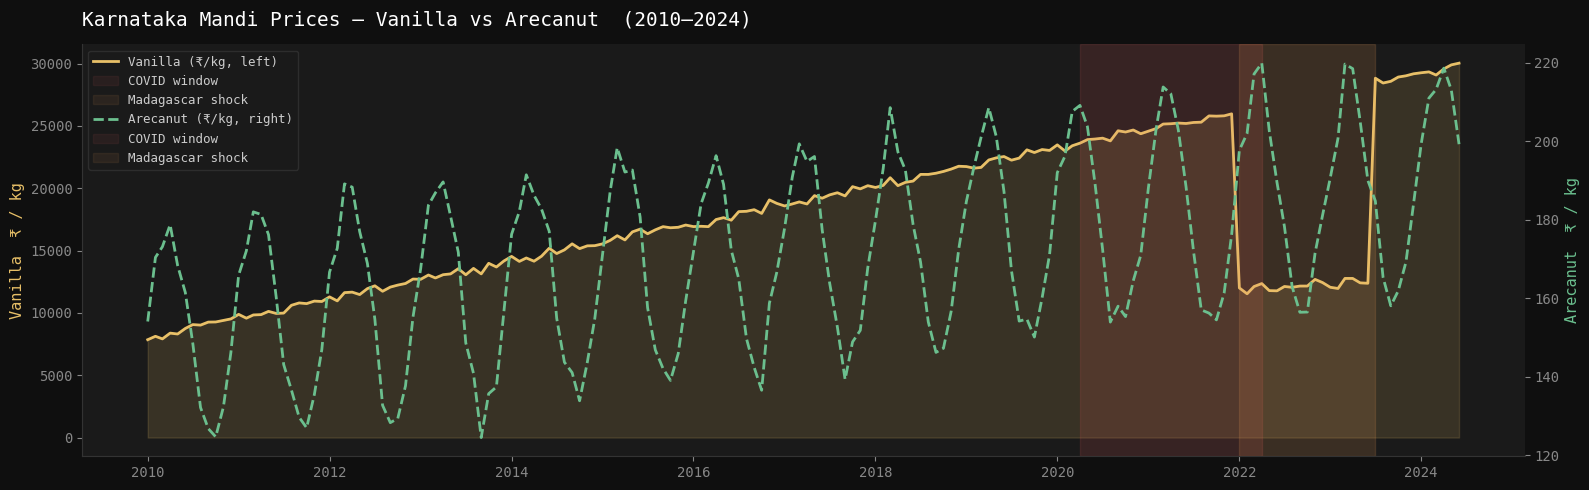

✓ Plot 1 — Price history saved


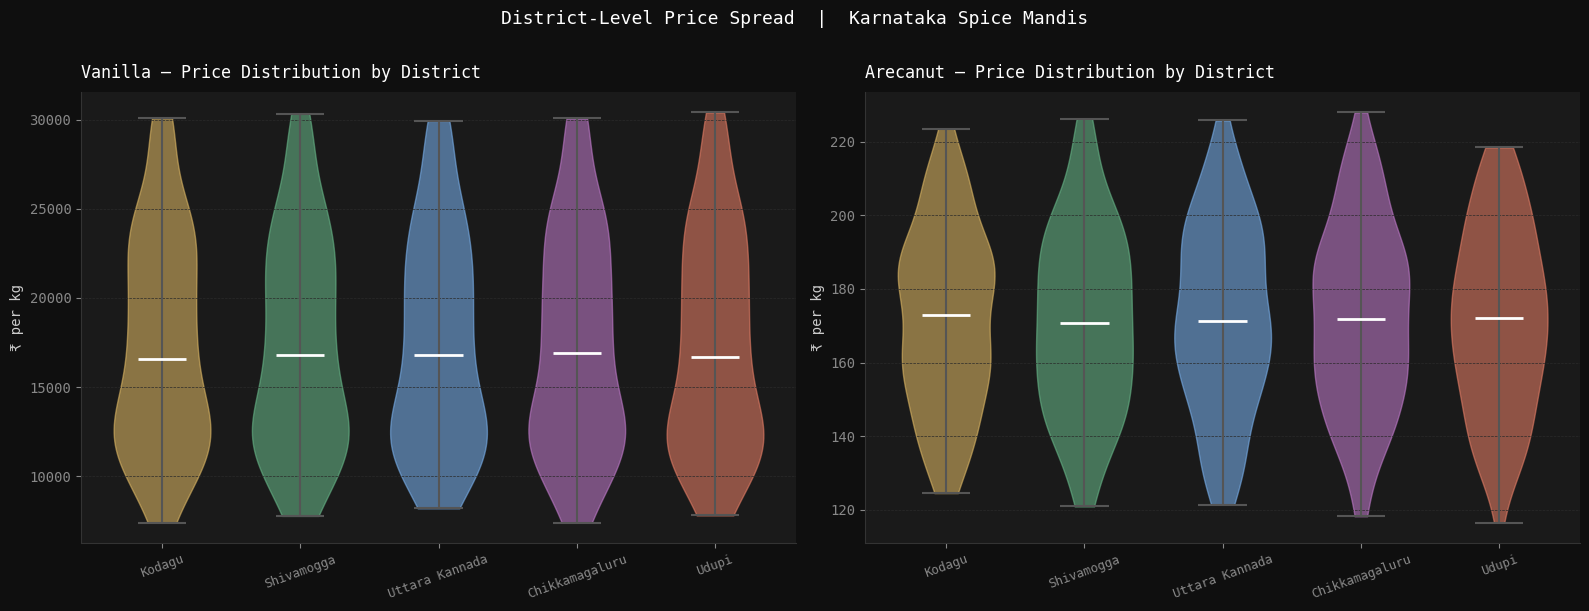

✓ Plot 2 — District distributions saved


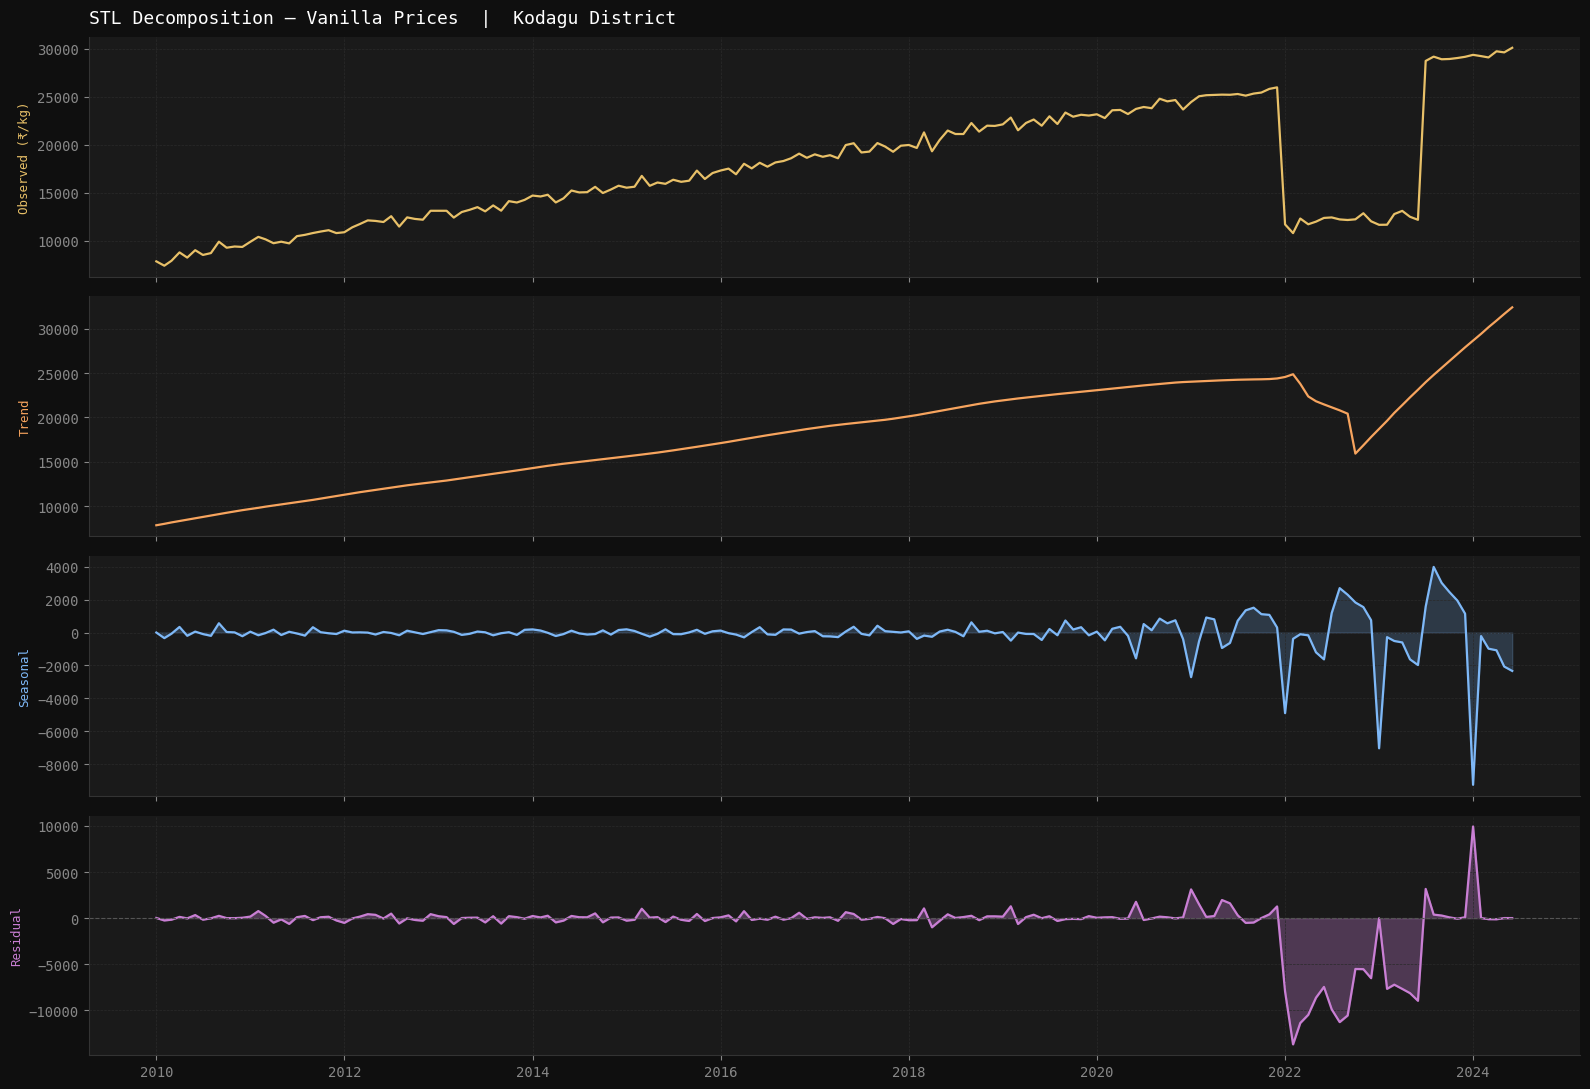

✓ Plot 3 — STL decomposition saved


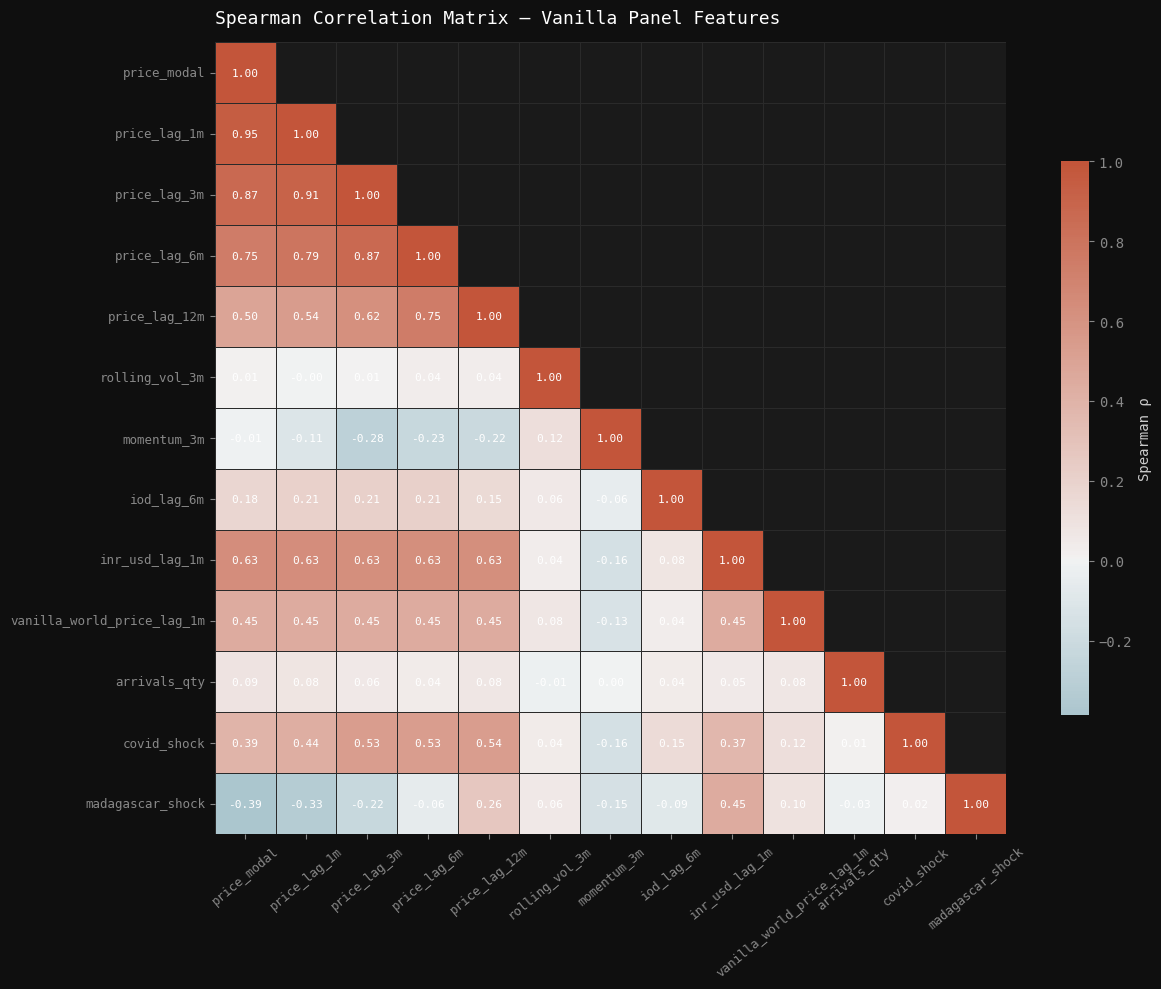

✓ Plot 4 — Correlation heatmap saved


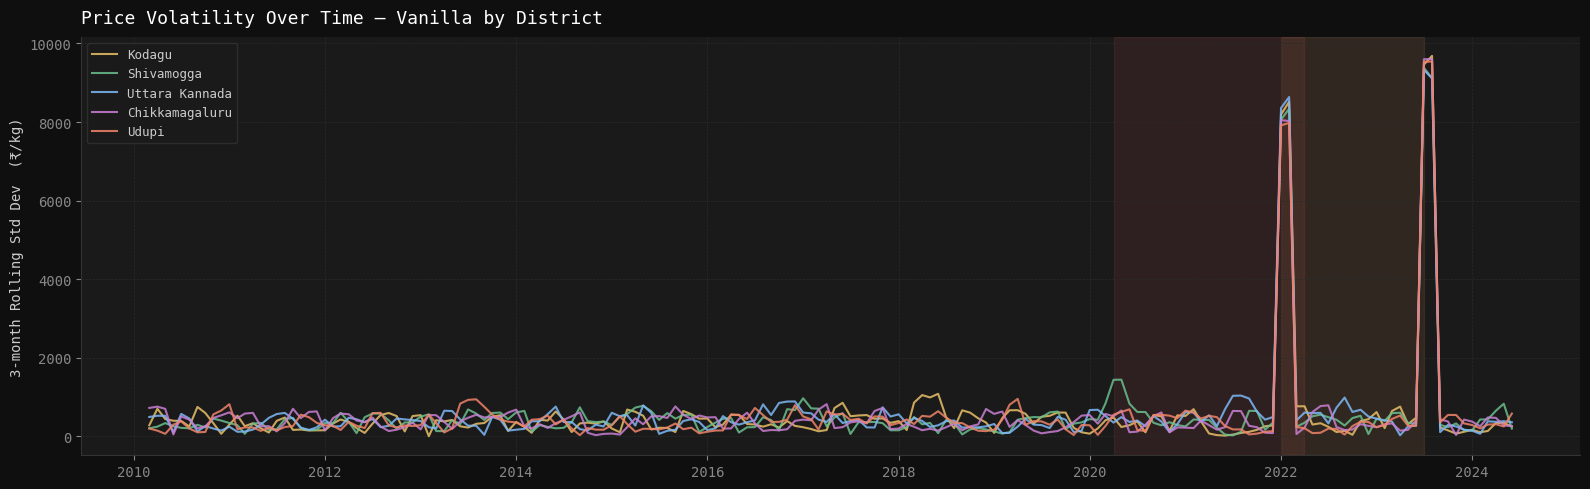

✓ Plot 5 — Volatility plot saved


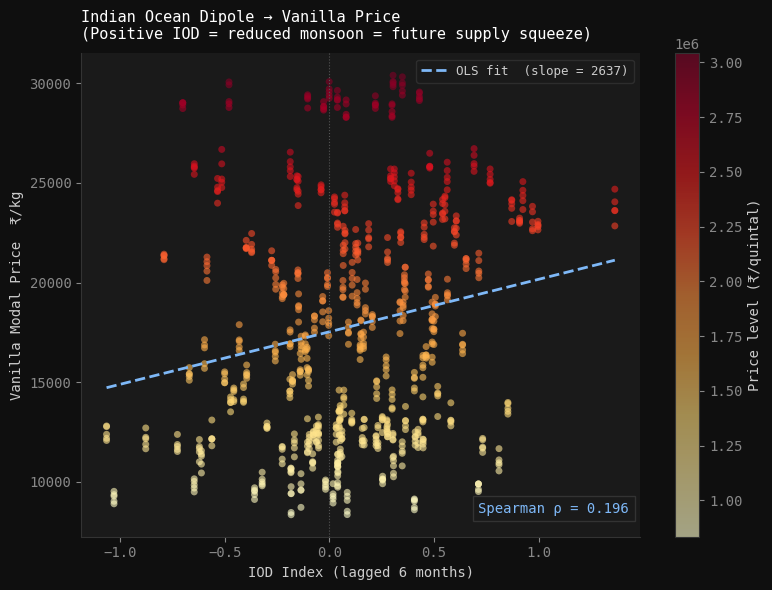

✓ Plot 6 — IOD scatter saved


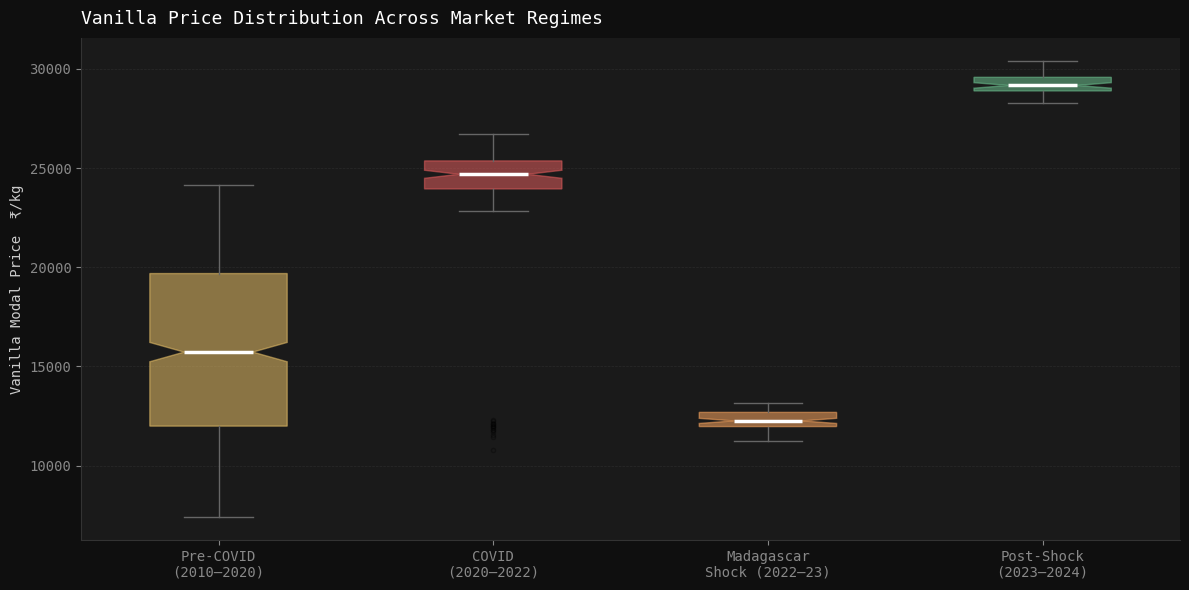

✓ Plot 7 — Shock period comparison saved


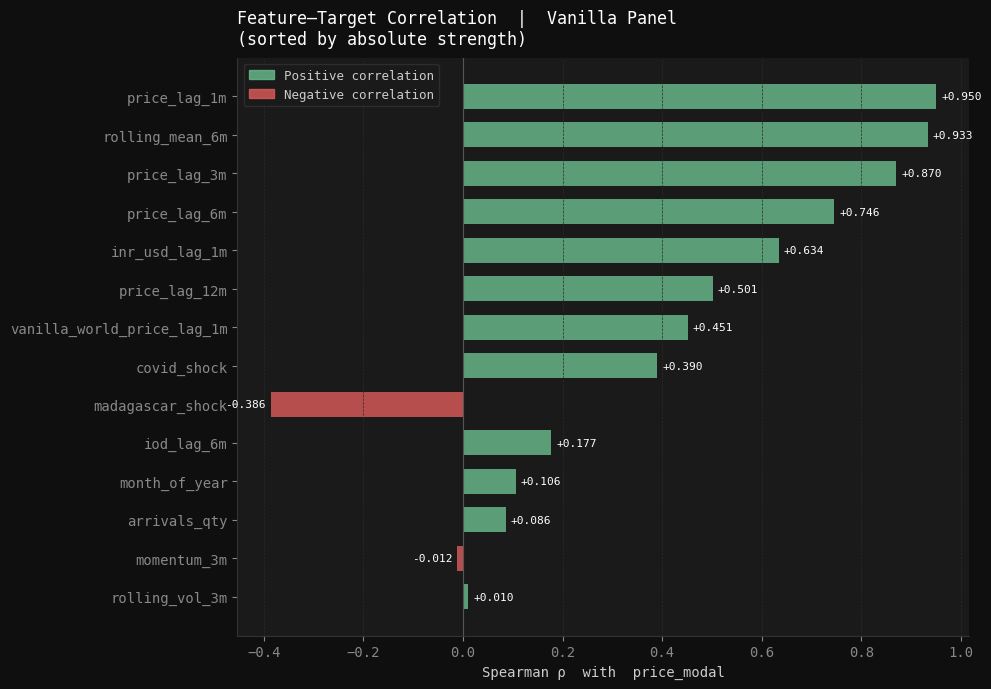

✓ Plot 8 — Feature correlation bar chart saved

  ✓ EDA complete — 8 plots saved to outputs/
  plot1_price_history.png        — Dual-axis time series
  plot2_district_distributions.png — District violins
  plot3_stl_decomposition.png    — Trend / seasonal / residual
  plot4_correlation_heatmap.png  — Spearman matrix
  plot5_volatility.png           — Rolling std dev by district
  plot6_iod_scatter.png          — Climate→price scatter
  plot7_shock_comparison.png     — Regime box plots
  plot8_feature_correlation.png  — Feature–target bar chart


In [7]:
# ============================================================
# CELL 4 — EXPLORATORY DATA ANALYSIS
# 8 publication-quality plots covering:
#   1. Price history (vanilla vs arecanut)
#   2. District price distributions
#   3. Seasonal decomposition (STL)
#   4. Correlation heatmap
#   5. Volatility over time
#   6. IOD → price lag relationship
#   7. Shock period comparison
#   8. Feature correlation with target
# ============================================================

# Load the panel built in Cell 3
df = pd.read_parquet(PROC_DIR / "panel_monthly.parquet")
df_v = df[df["commodity"] == "vanilla"].copy()
df_a = df[df["commodity"] == "arecanut"].copy()

# ── Global style ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : "#0f0f0f",
    "axes.facecolor"    : "#1a1a1a",
    "axes.edgecolor"    : "#333333",
    "axes.labelcolor"   : "#cccccc",
    "axes.titlecolor"   : "#ffffff",
    "xtick.color"       : "#888888",
    "ytick.color"       : "#888888",
    "text.color"        : "#cccccc",
    "grid.color"        : "#2a2a2a",
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.5,
    "font.family"       : "monospace",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

VANILLA_COL  = "#e8c068"    # warm gold
ARECANUT_COL = "#6bbf8e"    # sage green
SHOCK_COL    = "#e05c5c"    # red for shocks
IOD_COL      = "#7eb8f7"    # sky blue

DISTRICTS_PALETTE = {
    "Kodagu"          : "#e8c068",
    "Shivamogga"      : "#6bbf8e",
    "Uttara Kannada"  : "#7eb8f7",
    "Chikkamagaluru"  : "#c97fd4",
    "Udupi"           : "#f0836a",
}


# ════════════════════════════════════════════════════════════
# PLOT 1 — Price history: vanilla vs arecanut (dual axis)
# ════════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor("#0f0f0f")
ax2 = ax1.twinx()

van_agg = df_v.groupby("month")["price_modal"].median().reset_index()
are_agg = df_a.groupby("month")["price_modal"].median().reset_index()

ax1.plot(van_agg["month"], van_agg["price_modal"] / 100,
         color=VANILLA_COL, linewidth=2.0, label="Vanilla (₹/kg, left)")
ax1.fill_between(van_agg["month"], van_agg["price_modal"] / 100,
                 alpha=0.15, color=VANILLA_COL)

ax2.plot(are_agg["month"], are_agg["price_modal"] / 100,
         color=ARECANUT_COL, linewidth=2.0, label="Arecanut (₹/kg, right)",
         linestyle="--")

# Shock bands
for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp("2020-04-01"), pd.Timestamp("2022-03-31"),
               alpha=0.08, color=SHOCK_COL, label="COVID window")
    ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2023-06-30"),
               alpha=0.08, color="#f7a45e", label="Madagascar shock")

ax1.set_ylabel("Vanilla  ₹ / kg", color=VANILLA_COL, fontsize=11)
ax2.set_ylabel("Arecanut  ₹ / kg", color=ARECANUT_COL, fontsize=11)
ax1.set_xlabel("")
ax1.set_title("Karnataka Mandi Prices — Vanilla vs Arecanut  (2010–2024)",
              fontsize=14, pad=14, color="white", loc="left")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           facecolor="#1a1a1a", edgecolor="#333", fontsize=9, loc="upper left")

ax1.yaxis.label.set_color(VANILLA_COL)
ax2.yaxis.label.set_color(ARECANUT_COL)
plt.tight_layout()
plt.savefig(OUT_DIR / "plot1_price_history.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()
print("✓ Plot 1 — Price history saved")


# ════════════════════════════════════════════════════════════
# PLOT 2 — District violin distributions (vanilla)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f0f0f")

for ax, (commodity, df_c, color) in zip(axes, [
    ("Vanilla",  df_v, VANILLA_COL),
    ("Arecanut", df_a, ARECANUT_COL),
]):
    districts_present = [d for d in DISTRICTS if d in df_c["district"].unique()]
    data_by_district  = [
        df_c.loc[df_c["district"] == d, "price_modal"].dropna().values / 100
        for d in districts_present
    ]

    parts = ax.violinplot(data_by_district, showmedians=True,
                          showextrema=True, widths=0.7)

    for i, pc in enumerate(parts["bodies"]):
        d   = districts_present[i]
        col = DISTRICTS_PALETTE.get(d, color)
        pc.set_facecolor(col)
        pc.set_alpha(0.55)
        pc.set_edgecolor(col)

    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(2)
    parts["cmaxes"].set_color("#555")
    parts["cmins"].set_color("#555")
    parts["cbars"].set_color("#555")

    ax.set_xticks(range(1, len(districts_present) + 1))
    ax.set_xticklabels(districts_present, fontsize=9, rotation=20)
    ax.set_ylabel("₹ per kg", fontsize=10)
    ax.set_title(f"{commodity} — Price Distribution by District",
                 fontsize=12, pad=10, color="white", loc="left")
    ax.grid(axis="y")

fig.suptitle("District-Level Price Spread  |  Karnataka Spice Mandis",
             fontsize=13, color="white", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "plot2_district_distributions.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("✓ Plot 2 — District distributions saved")


# ════════════════════════════════════════════════════════════
# PLOT 3 — STL Seasonal Decomposition (vanilla, Kodagu)
# ════════════════════════════════════════════════════════════
series_stl = (
    df_v[df_v["district"] == DISTRICTS[0]]
    .set_index("month")["price_modal"]
    .resample("MS").mean()
    .fillna(method="ffill")
)

if len(series_stl) >= 24:
    stl    = STL(series_stl, period=12, robust=True)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True)
    fig.patch.set_facecolor("#0f0f0f")

    components = [
        (series_stl / 100,       "Observed (₹/kg)",   VANILLA_COL),
        (result.trend / 100,     "Trend",              "#f7a45e"),
        (result.seasonal / 100,  "Seasonal",           IOD_COL),
        (result.resid / 100,     "Residual",           "#c97fd4"),
    ]

    for ax, (data, label, color) in zip(axes, components):
        ax.plot(data.index, data.values, color=color, linewidth=1.6)
        if label == "Seasonal":
            ax.fill_between(data.index, data.values, alpha=0.2, color=color)
        if label == "Residual":
            ax.axhline(0, color="#555", linewidth=0.8, linestyle="--")
            ax.fill_between(data.index, data.values, alpha=0.3, color=color)
        ax.set_ylabel(label, fontsize=9, color=color)
        ax.grid(True)

    axes[0].set_title(
        f"STL Decomposition — Vanilla Prices  |  {DISTRICTS[0]} District",
        fontsize=13, color="white", pad=10, loc="left"
    )
    plt.tight_layout()
    plt.savefig(OUT_DIR / "plot3_stl_decomposition.png", dpi=150,
                bbox_inches="tight", facecolor="#0f0f0f")
    plt.show()
    print("✓ Plot 3 — STL decomposition saved")
else:
    print("⚠ Plot 3 skipped — not enough data for STL (need ≥24 months)")


# ════════════════════════════════════════════════════════════
# PLOT 4 — Correlation heatmap (feature × target)
# ════════════════════════════════════════════════════════════
CORR_FEATURES = [
    "price_modal", "price_lag_1m", "price_lag_3m", "price_lag_6m",
    "price_lag_12m", "rolling_vol_3m", "momentum_3m",
    "iod_lag_6m", "inr_usd_lag_1m", "vanilla_world_price_lag_1m",
    "arrivals_qty", "covid_shock", "madagascar_shock",
]

corr_df = df_v[[c for c in CORR_FEATURES if c in df_v.columns]].dropna()
corr_matrix = corr_df.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor("#0f0f0f")

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 8, "color": "white"},
    linewidths=0.5, linecolor="#2a2a2a",
    square=True, ax=ax,
    cbar_kws={"shrink": 0.7, "label": "Spearman ρ"},
)
ax.set_title("Spearman Correlation Matrix — Vanilla Panel Features",
             fontsize=13, color="white", pad=14, loc="left")
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "plot4_correlation_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("✓ Plot 4 — Correlation heatmap saved")


# ════════════════════════════════════════════════════════════
# PLOT 5 — Rolling volatility over time (all districts)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor("#0f0f0f")

for district, color in DISTRICTS_PALETTE.items():
    sub = df_v[df_v["district"] == district].sort_values("month")
    if "rolling_vol_3m" in sub.columns and sub["rolling_vol_3m"].notna().sum() > 5:
        ax.plot(sub["month"], sub["rolling_vol_3m"] / 100,
                label=district, color=color, linewidth=1.5, alpha=0.85)

ax.axvspan(pd.Timestamp("2020-04-01"), pd.Timestamp("2022-03-31"),
           alpha=0.1, color=SHOCK_COL)
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2023-06-30"),
           alpha=0.1, color="#f7a45e")

ax.set_ylabel("3-month Rolling Std Dev  (₹/kg)", fontsize=10)
ax.set_title("Price Volatility Over Time — Vanilla by District",
             fontsize=13, color="white", pad=10, loc="left")
ax.legend(facecolor="#1a1a1a", edgecolor="#333", fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "plot5_volatility.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("✓ Plot 5 — Volatility plot saved")


# ════════════════════════════════════════════════════════════
# PLOT 6 — IOD → Vanilla price scatter with 6-month lag
# ════════════════════════════════════════════════════════════
if "iod_lag_6m" in df_v.columns:
    iod_data = df_v[["iod_lag_6m", "price_modal"]].dropna()

    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor("#0f0f0f")

    sc = ax.scatter(
        iod_data["iod_lag_6m"],
        iod_data["price_modal"] / 100,
        c=iod_data["price_modal"],
        cmap="YlOrRd", alpha=0.6, s=25, edgecolors="none",
    )

    # Regression line
    z = np.polyfit(iod_data["iod_lag_6m"], iod_data["price_modal"] / 100, 1)
    p = np.poly1d(z)
    x_line = np.linspace(iod_data["iod_lag_6m"].min(),
                         iod_data["iod_lag_6m"].max(), 100)
    ax.plot(x_line, p(x_line), color=IOD_COL, linewidth=2, linestyle="--",
            label=f"OLS fit  (slope = {z[0]:.0f})")

    ax.axvline(0, color="#555", linewidth=0.8, linestyle=":")
    ax.set_xlabel("IOD Index (lagged 6 months)", fontsize=10)
    ax.set_ylabel("Vanilla Modal Price  ₹/kg", fontsize=10)
    ax.set_title("Indian Ocean Dipole → Vanilla Price\n(Positive IOD = reduced monsoon = future supply squeeze)",
                 fontsize=11, color="white", pad=10, loc="left")

    corr_val = iod_data.corr(method="spearman").loc["iod_lag_6m", "price_modal"]
    ax.text(0.98, 0.05, f"Spearman ρ = {corr_val:.3f}",
            transform=ax.transAxes, ha="right", fontsize=10,
            color=IOD_COL, bbox=dict(facecolor="#1a1a1a", edgecolor="#333", pad=4))

    plt.colorbar(sc, ax=ax, label="Price level (₹/quintal)")
    ax.legend(facecolor="#1a1a1a", edgecolor="#333", fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "plot6_iod_scatter.png", dpi=150,
                bbox_inches="tight", facecolor="#0f0f0f")
    plt.show()
    print("✓ Plot 6 — IOD scatter saved")


# ════════════════════════════════════════════════════════════
# PLOT 7 — Shock period price comparison (box plots)
# ════════════════════════════════════════════════════════════
def label_period(month):
    if month < pd.Timestamp("2020-04-01"):
        return "Pre-COVID\n(2010–2020)"
    elif month <= pd.Timestamp("2022-03-31"):
        return "COVID\n(2020–2022)"
    elif month <= pd.Timestamp("2023-06-30"):
        return "Madagascar\nShock (2022–23)"
    else:
        return "Post-Shock\n(2023–2024)"

df_v["period"] = df_v["month"].apply(label_period)
period_order = ["Pre-COVID\n(2010–2020)", "COVID\n(2020–2022)",
                "Madagascar\nShock (2022–23)", "Post-Shock\n(2023–2024)"]
period_colors = [VANILLA_COL, SHOCK_COL, "#f7a45e", ARECANUT_COL]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0f0f0f")

bp = ax.boxplot(
    [df_v.loc[df_v["period"] == p, "price_modal"].dropna().values / 100
     for p in period_order],
    patch_artist=True, notch=True, widths=0.5,
    medianprops=dict(color="white", linewidth=2.5),
    whiskerprops=dict(color="#666"),
    capprops=dict(color="#666"),
    flierprops=dict(marker="o", markersize=3, alpha=0.3),
)

for patch, color in zip(bp["boxes"], period_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
    patch.set_edgecolor(color)

ax.set_xticks(range(1, len(period_order) + 1))
ax.set_xticklabels(period_order, fontsize=10)
ax.set_ylabel("Vanilla Modal Price  ₹/kg", fontsize=10)
ax.set_title("Vanilla Price Distribution Across Market Regimes",
             fontsize=13, color="white", pad=10, loc="left")
ax.grid(axis="y")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot7_shock_comparison.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("✓ Plot 7 — Shock period comparison saved")


# ════════════════════════════════════════════════════════════
# PLOT 8 — Feature importance preview (correlation bar chart)
# ════════════════════════════════════════════════════════════
TARGET = "price_modal"
FEATS  = [c for c in [
    "price_lag_1m", "price_lag_3m", "price_lag_6m", "price_lag_12m",
    "rolling_vol_3m", "rolling_mean_6m", "momentum_3m",
    "iod_lag_6m", "inr_usd_lag_1m", "vanilla_world_price_lag_1m",
    "arrivals_qty", "covid_shock", "madagascar_shock", "month_of_year",
] if c in df_v.columns]

corr_target = (
    df_v[FEATS + [TARGET]].dropna()
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0f0f0f")

colors = [ARECANUT_COL if v >= 0 else SHOCK_COL for v in corr_target.values]
bars   = ax.barh(corr_target.index, corr_target.values,
                 color=colors, alpha=0.8, edgecolor="none", height=0.65)

ax.axvline(0, color="#555", linewidth=0.8)
for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center",
            ha="left" if val >= 0 else "right",
            fontsize=8, color="white")

ax.set_xlabel("Spearman ρ  with  price_modal", fontsize=10)
ax.set_title("Feature–Target Correlation  |  Vanilla Panel\n(sorted by absolute strength)",
             fontsize=12, color="white", pad=10, loc="left")
ax.grid(axis="x")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=ARECANUT_COL, alpha=0.8, label="Positive correlation"),
    Patch(color=SHOCK_COL,    alpha=0.8, label="Negative correlation"),
], facecolor="#1a1a1a", edgecolor="#333", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "plot8_feature_correlation.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("✓ Plot 8 — Feature correlation bar chart saved")


# ── Final summary ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  ✓ EDA complete — 8 plots saved to outputs/")
print(f"{'='*60}")
print(f"  plot1_price_history.png        — Dual-axis time series")
print(f"  plot2_district_distributions.png — District violins")
print(f"  plot3_stl_decomposition.png    — Trend / seasonal / residual")
print(f"  plot4_correlation_heatmap.png  — Spearman matrix")
print(f"  plot5_volatility.png           — Rolling std dev by district")
print(f"  plot6_iod_scatter.png          — Climate→price scatter")
print(f"  plot7_shock_comparison.png     — Regime box plots")
print(f"  plot8_feature_correlation.png  — Feature–target bar chart")
print(f"{'='*60}")

Running stationarity tests ...

  STATIONARITY TEST RESULTS
                          series  n_obs  ADF p-value ADF stationary  KPSS p-value KPSS stationary  LB p (lag 12) Autocorrelated
                Kodagu | vanilla    174       0.4196           ✗ NO        0.0100            ✗ NO         0.0000          ✓ YES
         Kodagu | vanilla (Δlog)    173       0.0000          ✓ YES        0.1000           ✓ YES         0.9899           ✗ NO
               Kodagu | arecanut    174       0.9348           ✗ NO        0.0100            ✗ NO         0.0000          ✓ YES
        Kodagu | arecanut (Δlog)    173       0.0000          ✓ YES        0.1000           ✓ YES         0.0000          ✓ YES
            Shivamogga | vanilla    174       0.4403           ✗ NO        0.0100            ✗ NO         0.0000          ✓ YES
     Shivamogga | vanilla (Δlog)    173       0.0000          ✓ YES        0.1000           ✓ YES         0.9820           ✗ NO
           Shivamogga | arecanut    174     

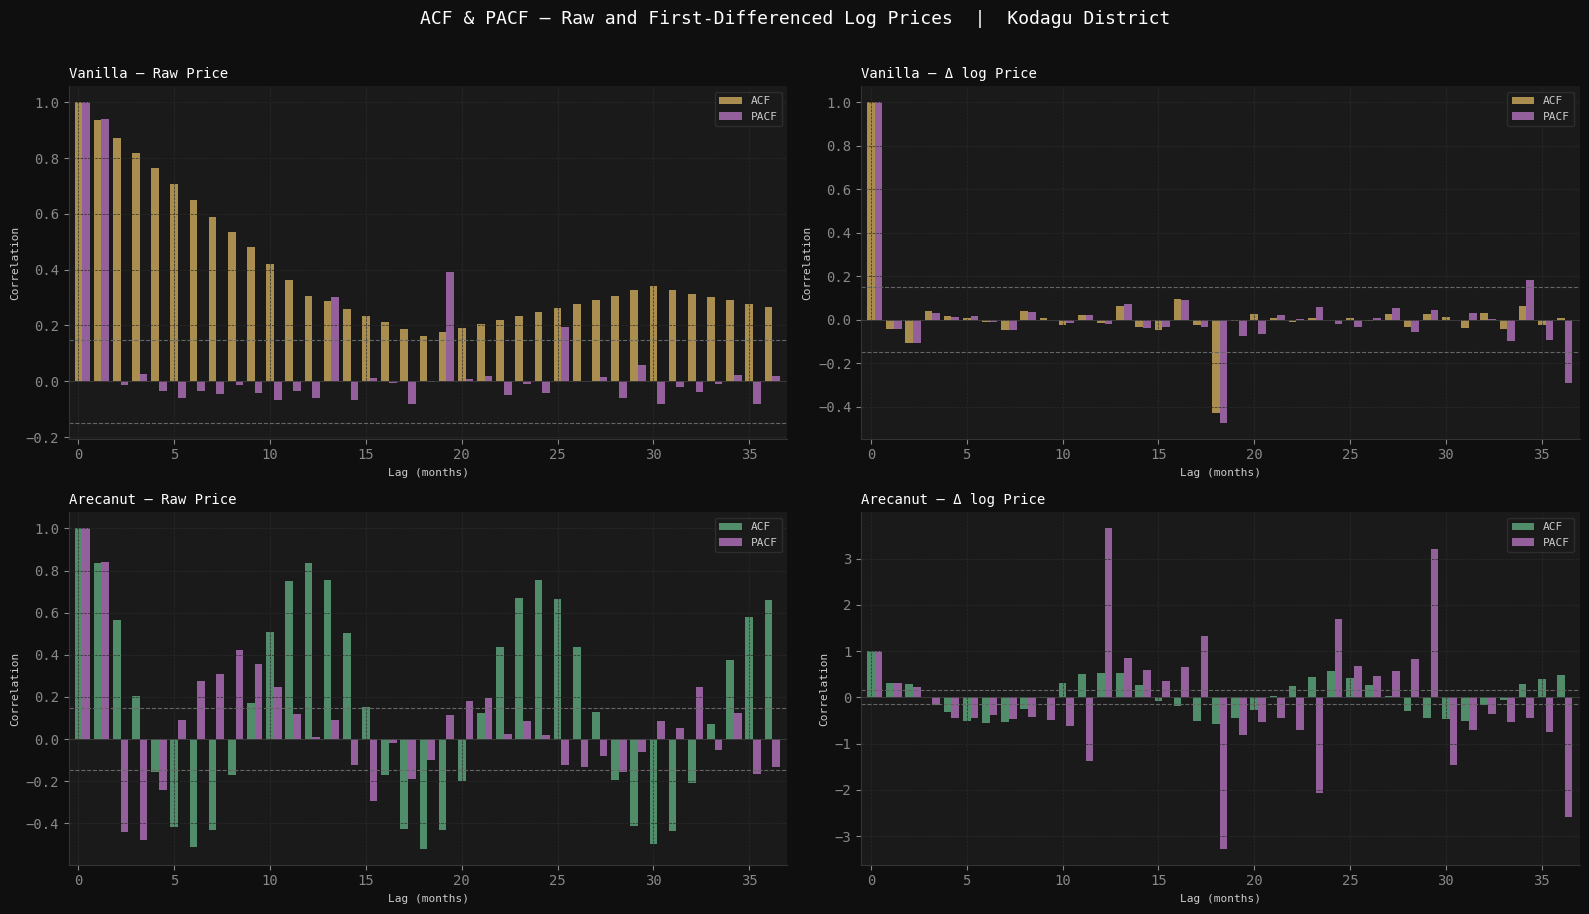


────────────────────────────────────────────────────────────
  INTERPRETATION GUIDE
────────────────────────────────────────────────────────────
  Raw series:
    ACF decays slowly  → non-stationary (unit root likely)
    Spike at lag 12    → annual seasonality present
  Δ log series (differenced):
    ACF cuts off at lag q  → MA(q) component
    PACF cuts off at lag p → AR(p) component
    Both decay           → ARMA(p,q) needed
────────────────────────────────────────────────────────────
✓ Cell 5 complete — stationarity tests + ACF/PACF saved


In [8]:
# ============================================================
# CELL 5 — STATIONARITY TESTS + ACF / PACF
# Required before any ARIMA / SARIMAX fitting.
# Tests: ADF, KPSS, Ljung-Box
# Visuals: ACF + PACF for vanilla and arecanut (Kodagu)
# ============================================================

df = pd.read_parquet(PROC_DIR / "panel_monthly.parquet")

# ── Helper: run ADF + KPSS and return a clean summary row ────
def stationarity_tests(series: pd.Series, name: str) -> dict:
    s = series.dropna()
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(s, autolag="AIC")
    kpss_stat, kpss_p, _, kpss_crit    = kpss(s, regression="c", nlags="auto")
    lb = acorr_ljungbox(s, lags=[12], return_df=True)
    return {
        "series"        : name,
        "n_obs"         : len(s),
        "ADF stat"      : round(adf_stat, 4),
        "ADF p-value"   : round(adf_p, 4),
        "ADF 5% crit"   : round(adf_crit["5%"], 4),
        "ADF stationary": "✓ YES" if adf_p < 0.05 else "✗ NO",
        "KPSS stat"     : round(kpss_stat, 4),
        "KPSS p-value"  : round(kpss_p, 4),
        "KPSS stationary": "✓ YES" if kpss_p > 0.05 else "✗ NO",
        "LB p (lag 12)" : round(lb["lb_pvalue"].values[0], 4),
        "Autocorrelated": "✓ YES" if lb["lb_pvalue"].values[0] < 0.05 else "✗ NO",
    }


# Run tests on key series
print("Running stationarity tests ...\n")
results = []

for district in DISTRICTS:
    for commodity in CROPS:
        sub = (df[(df["district"] == district) &
                   (df["commodity"] == commodity)]
               .sort_values("month")
               .set_index("month")["price_modal"]
               .dropna())
        if len(sub) >= 24:
            results.append(stationarity_tests(sub, f"{district} | {commodity}"))

            # Also test log-differenced series
            sub_diff = np.log(sub).diff().dropna()
            results.append(stationarity_tests(sub_diff,
                           f"{district} | {commodity} (Δlog)"))

df_tests = pd.DataFrame(results)

print("=" * 90)
print("  STATIONARITY TEST RESULTS")
print("=" * 90)
print(df_tests[[
    "series", "n_obs",
    "ADF p-value", "ADF stationary",
    "KPSS p-value", "KPSS stationary",
    "LB p (lag 12)", "Autocorrelated"
]].to_string(index=False))
print("=" * 90)
print("  ADF  H0: unit root present  → reject H0 (p<0.05) = stationary")
print("  KPSS H0: series stationary  → fail to reject (p>0.05) = stationary")
print("  Agreement between ADF and KPSS = strong evidence of stationarity")


# ── ACF / PACF plots ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.patch.set_facecolor("#0f0f0f")
fig.suptitle("ACF & PACF — Raw and First-Differenced Log Prices  |  Kodagu District",
             fontsize=13, color="white", y=1.01)

panel_configs = [
    ("vanilla",  "price_modal", False, "Vanilla — Raw Price",         axes[0, 0], VANILLA_COL),
    ("vanilla",  "price_modal", True,  "Vanilla — Δ log Price",       axes[0, 1], VANILLA_COL),
    ("arecanut", "price_modal", False, "Arecanut — Raw Price",        axes[1, 0], ARECANUT_COL),
    ("arecanut", "price_modal", True,  "Arecanut — Δ log Price",      axes[1, 1], ARECANUT_COL),
]

for commodity, col, diff, title, ax, color in panel_configs:
    sub = (df[(df["district"] == DISTRICTS[0]) &
               (df["commodity"] == commodity)]
           .sort_values("month")
           .set_index("month")[col]
           .dropna())

    if diff:
        sub = np.log(sub).diff().dropna()

    if len(sub) < 12:
        ax.text(0.5, 0.5, "Insufficient data", transform=ax.transAxes,
                ha="center", color="#888")
        continue

    lags  = min(36, len(sub) // 3)
    acf_  = acf(sub,  nlags=lags, fft=True)
    pacf_ = pacf(sub, nlags=lags)

    lag_range = np.arange(len(acf_))
    ci        = 1.96 / np.sqrt(len(sub))

    # ACF bars
    ax.bar(lag_range, acf_,  color=color,  alpha=0.7, width=0.4, label="ACF")
    # PACF bars (offset)
    ax.bar(lag_range + 0.4, pacf_, color="#c97fd4", alpha=0.7, width=0.4, label="PACF")
    # Confidence bands
    ax.axhline( ci, color="#666", linestyle="--", linewidth=0.8)
    ax.axhline(-ci, color="#666", linestyle="--", linewidth=0.8)
    ax.axhline( 0,  color="#444", linewidth=0.5)

    ax.set_title(title, fontsize=10, color="white", pad=6, loc="left")
    ax.set_xlabel("Lag (months)", fontsize=8)
    ax.set_ylabel("Correlation", fontsize=8)
    ax.set_xlim(-0.5, lags + 1)
    ax.legend(fontsize=8, facecolor="#1a1a1a", edgecolor="#333")
    ax.grid(True)

plt.tight_layout()
plt.savefig(OUT_DIR / "plot9_acf_pacf.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

# ── Interpretation guide ─────────────────────────────────────
print(f"\n{'─'*60}")
print("  INTERPRETATION GUIDE")
print(f"{'─'*60}")
print("  Raw series:")
print("    ACF decays slowly  → non-stationary (unit root likely)")
print("    Spike at lag 12    → annual seasonality present")
print("  Δ log series (differenced):")
print("    ACF cuts off at lag q  → MA(q) component")
print("    PACF cuts off at lag p → AR(p) component")
print("    Both decay           → ARMA(p,q) needed")
print(f"{'─'*60}")
print("✓ Cell 5 complete — stationarity tests + ACF/PACF saved")

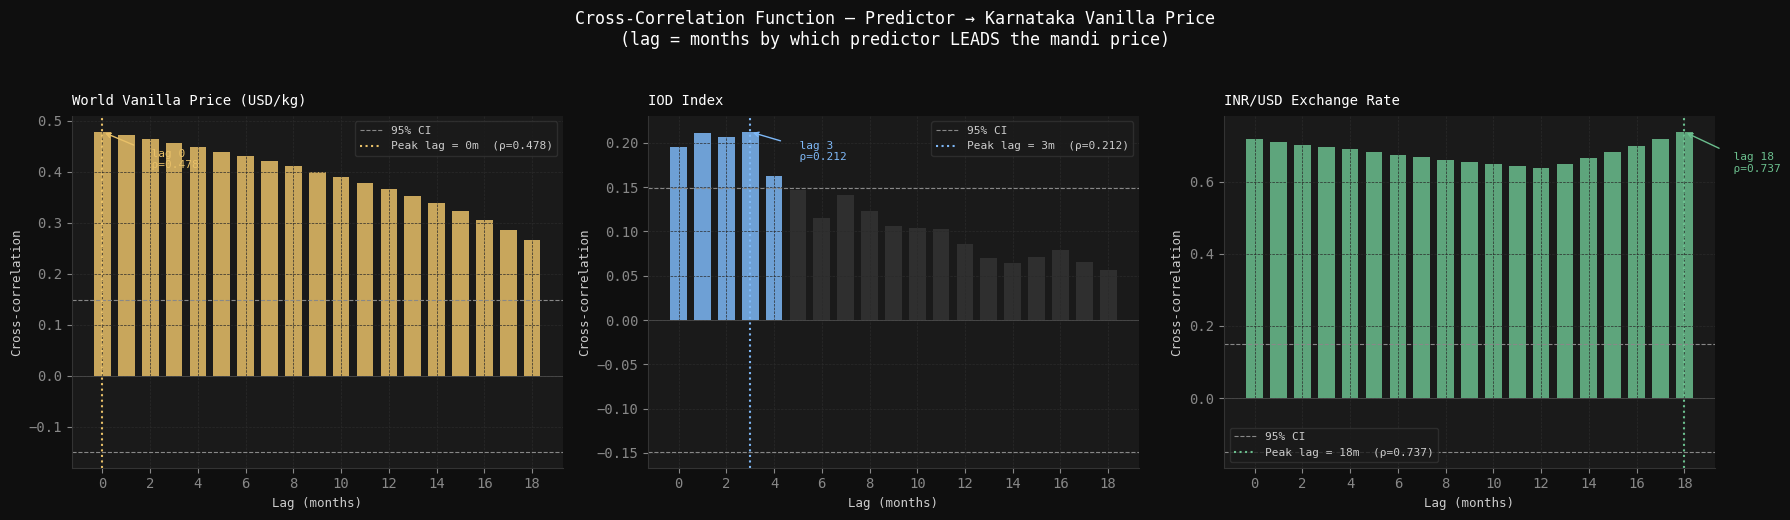

✓ Plot 10 — Cross-correlation saved

  GRANGER CAUSALITY TESTS
  H0: predictor does NOT Granger-cause vanilla mandi price
  Reject H0 (p < 0.05) → predictor has predictive power
                   predictor  lag  F-stat  p-value significant
World Vanilla Price (USD/kg)    1  0.7018   0.4034           ✗
World Vanilla Price (USD/kg)    2  0.4053   0.6674           ✗
World Vanilla Price (USD/kg)    3  0.2795   0.8401           ✗
World Vanilla Price (USD/kg)    4  0.2460   0.9117           ✗
World Vanilla Price (USD/kg)    5  0.2138   0.9563           ✗
World Vanilla Price (USD/kg)    6  0.2134   0.9721           ✗
                   IOD Index    1  2.6778   0.1036           ✗
                   IOD Index    2  1.7347   0.1796           ✗
                   IOD Index    3  1.1876   0.3162           ✗
                   IOD Index    4  0.9436   0.4403           ✗
                   IOD Index    5  0.7012   0.6233           ✗
                   IOD Index    6  0.6660   0.6772           ✗
   

In [9]:
# ============================================================
# CELL 6 — CROSS-CORRELATION & LAG STRUCTURE ANALYSIS
# Formally proves which lag of world vanilla price / IOD / INR
# most strongly predicts Karnataka mandi prices.
# Also runs Granger causality tests.
# ============================================================

df = pd.read_parquet(PROC_DIR / "panel_monthly.parquet")

# Aggregate vanilla to single national series (median across districts)
van_nat = (df[df["commodity"] == "vanilla"]
           .groupby("month")[["price_modal",
                               "vanilla_world_price_usd_kg",
                               "iod_index",
                               "inr_usd_rate"]]
           .median()
           .sort_index()
           .dropna(subset=["price_modal"]))

# ── 1. Cross-correlation function (CCF) ──────────────────────
def ccf_values(x: pd.Series, y: pd.Series, max_lag: int = 18) -> pd.DataFrame:
    """
    Compute cross-correlation of x with y at lags 0..max_lag.
    Lag k means: how well does x_{t-k} predict y_t?
    """
    x_s = (x - x.mean()) / x.std()
    y_s = (y - y.mean()) / y.std()
    rows = []
    for lag in range(0, max_lag + 1):
        if lag == 0:
            aligned_x, aligned_y = x_s.values, y_s.values
        else:
            aligned_x = x_s.values[lag:]
            aligned_y = y_s.values[:-lag] if lag > 0 else y_s.values
            min_len   = min(len(aligned_x), len(aligned_y))
            aligned_x = aligned_x[:min_len]
            aligned_y = aligned_y[:min_len]
        corr = np.corrcoef(aligned_x, aligned_y)[0, 1]
        rows.append({"lag_months": lag, "ccf": corr})
    return pd.DataFrame(rows)


# Compute CCF for three exogenous predictors
predictors = {
    "World Vanilla Price (USD/kg)" : "vanilla_world_price_usd_kg",
    "IOD Index"                    : "iod_index",
    "INR/USD Exchange Rate"        : "inr_usd_rate",
}

ccf_results = {}
for label, col in predictors.items():
    if col in van_nat.columns:
        s = van_nat[[col, "price_modal"]].dropna()
        ccf_results[label] = ccf_values(s[col], s["price_modal"], max_lag=18)

# ── Plot CCF ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0f0f0f")
fig.suptitle("Cross-Correlation Function — Predictor → Karnataka Vanilla Price\n"
             "(lag = months by which predictor LEADS the mandi price)",
             fontsize=12, color="white", y=1.03)

colors_ccf = [VANILLA_COL, IOD_COL, ARECANUT_COL]

for ax, (label, ccf_df), color in zip(axes, ccf_results.items(), colors_ccf):
    ci = 1.96 / np.sqrt(len(van_nat))

    bars = ax.bar(ccf_df["lag_months"], ccf_df["ccf"],
                  color=[color if abs(v) > ci else "#333"
                         for v in ccf_df["ccf"]],
                  alpha=0.85, width=0.7, edgecolor="none")

    ax.axhline( ci, color="#888", linestyle="--", linewidth=0.8, label="95% CI")
    ax.axhline(-ci, color="#888", linestyle="--", linewidth=0.8)
    ax.axhline( 0,  color="#555", linewidth=0.5)

    # Mark the peak lag
    peak_row  = ccf_df.loc[ccf_df["ccf"].abs().idxmax()]
    peak_lag  = int(peak_row["lag_months"])
    peak_corr = peak_row["ccf"]
    ax.axvline(peak_lag, color=color, linewidth=1.5, linestyle=":",
               label=f"Peak lag = {peak_lag}m  (ρ={peak_corr:.3f})")
    ax.annotate(f"  lag {peak_lag}\n  ρ={peak_corr:.3f}",
                xy=(peak_lag, peak_corr),
                xytext=(peak_lag + 1.5, peak_corr * 0.85),
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle="->", color=color, lw=1))

    ax.set_xlabel("Lag (months)", fontsize=9)
    ax.set_ylabel("Cross-correlation", fontsize=9)
    ax.set_title(label, fontsize=10, color="white", pad=8, loc="left")
    ax.set_xticks(range(0, 19, 2))
    ax.legend(fontsize=8, facecolor="#1a1a1a", edgecolor="#333")
    ax.grid(True)

plt.tight_layout()
plt.savefig(OUT_DIR / "plot10_cross_correlation.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("✓ Plot 10 — Cross-correlation saved")


# ── 2. Granger causality tests ───────────────────────────────
print(f"\n{'='*65}")
print("  GRANGER CAUSALITY TESTS")
print("  H0: predictor does NOT Granger-cause vanilla mandi price")
print("  Reject H0 (p < 0.05) → predictor has predictive power")
print(f"{'='*65}")

max_lag_granger = 6
granger_rows    = []

for label, col in predictors.items():
    if col not in van_nat.columns:
        continue
    pair = van_nat[["price_modal", col]].dropna()
    if len(pair) < 24:
        continue
    try:
        gc_result = grangercausalitytests(
            pair[["price_modal", col]], maxlag=max_lag_granger, verbose=False
        )
        for lag in range(1, max_lag_granger + 1):
            f_stat = gc_result[lag][0]["ssr_ftest"][0]
            p_val  = gc_result[lag][0]["ssr_ftest"][1]
            granger_rows.append({
                "predictor" : label,
                "lag"       : lag,
                "F-stat"    : round(f_stat, 4),
                "p-value"   : round(p_val,  4),
                "significant": "✓" if p_val < 0.05 else "✗",
            })
    except Exception as e:
        print(f"  ⚠ Granger test failed for {label}: {e}")

df_granger = pd.DataFrame(granger_rows)
if not df_granger.empty:
    print(df_granger.to_string(index=False))
    print(f"\n  Best predictive lags (p < 0.05):")
    sig = df_granger[df_granger["p-value"] < 0.05]
    for pred, grp in sig.groupby("predictor"):
        lags_sig = grp["lag"].tolist()
        print(f"    {pred}: lags {lags_sig}")

print(f"{'='*65}")
print("✓ Cell 6 complete — cross-correlation + Granger causality done")

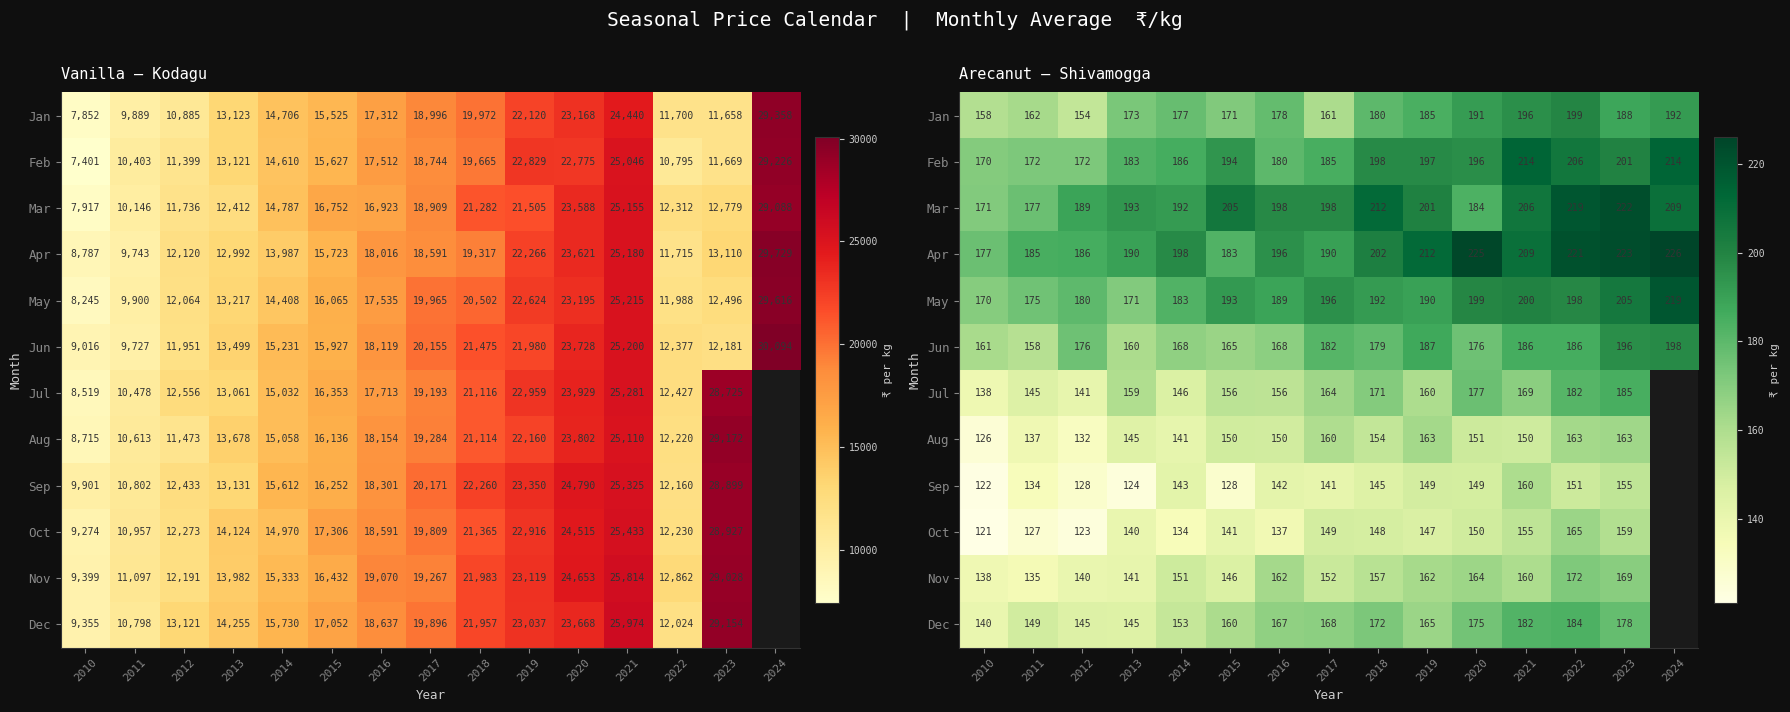

✓ Plot 11 — Calendar heatmap saved


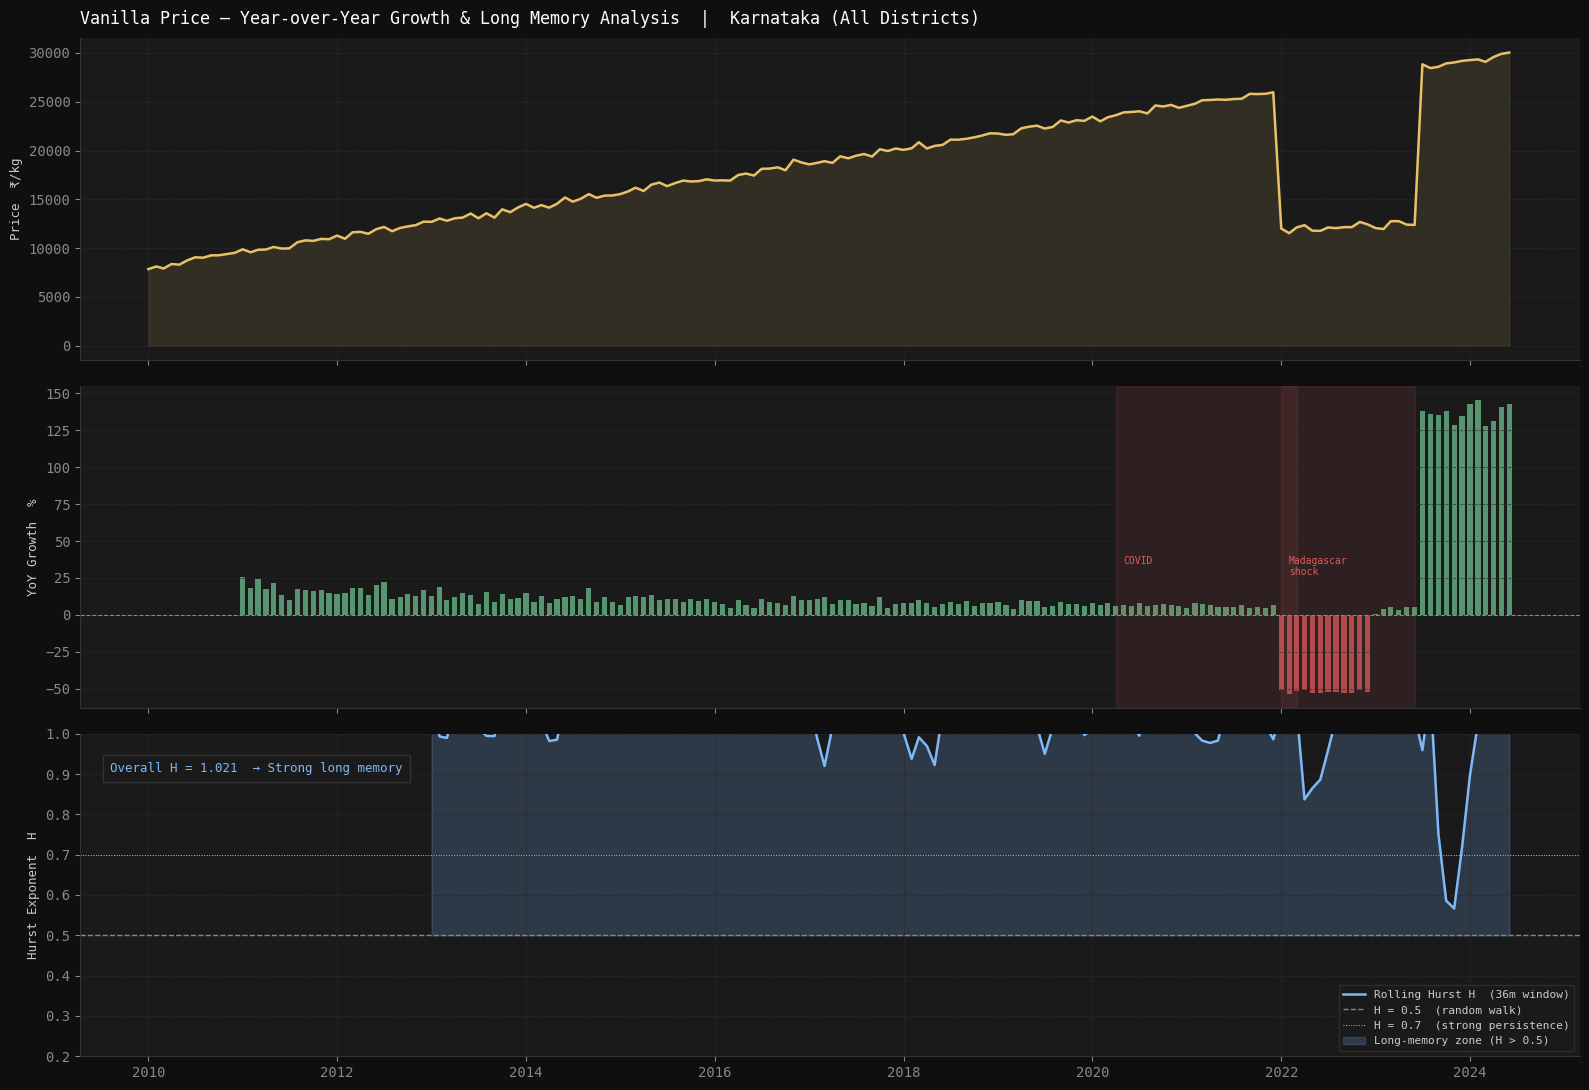


  LONG MEMORY SUMMARY
  Overall Hurst exponent (vanilla) : 1.0205
  → H > 0.5 confirms LONG MEMORY in vanilla price series
  → This theoretically justifies using LSTM / TFT over ARIMA
    because recurrent architectures exploit long-range dependence

✓ Cell 7 complete — calendar heatmap + Hurst analysis saved

────────────────────────────────────────────────────────────
  FULL EDA SUMMARY — ALL PLOTS
────────────────────────────────────────────────────────────
  Plot  1 : Price history (dual-axis time series)
  Plot  2 : District violin distributions
  Plot  3 : STL decomposition
  Plot  4 : Spearman correlation heatmap
  Plot  5 : Rolling volatility by district
  Plot  6 : IOD → price scatter
  Plot  7 : Shock period box plots
  Plot  8 : Feature–target correlation bars
  Plot  9 : ACF + PACF (raw and differenced)
  Plot 10 : Cross-correlation function (CCF)
  Plot 11 : Granger causality table (in Cell 6 output)
  Plot 12 : Calendar heatmap (month × year)
  Plot 13 : YoY growth + rol

In [10]:
# ============================================================
# CELL 7 — CALENDAR HEATMAP + YEAR-OVER-YEAR ANALYSIS
# Shows seasonal structure and annual growth rates.
# Two publication plots:
#   Plot 11 — Month × Year price heatmaps (vanilla + arecanut)
#   Plot 12 — YoY growth rate + rolling Hurst exponent
# ============================================================

df = pd.read_parquet(PROC_DIR / "panel_monthly.parquet")

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]


# ── Helper: build month × year pivot ─────────────────────────
def make_pivot(commodity: str, district: str) -> pd.DataFrame:
    sub = (df[(df["commodity"] == commodity) &
               (df["district"]  == district)]
           .copy())
    sub["year"]  = sub["month"].dt.year
    sub["month_n"] = sub["month"].dt.month
    pivot = sub.pivot_table(
        index="month_n", columns="year",
        values="price_modal", aggfunc="mean"
    )
    pivot.index = MONTH_LABELS
    return pivot / 100   # convert to ₹/kg


# ════════════════════════════════════════════════════════════
# PLOT 11 — Calendar heatmaps: vanilla (Kodagu) + arecanut (Shivamogga)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#0f0f0f")
fig.suptitle("Seasonal Price Calendar  |  Monthly Average  ₹/kg",
             fontsize=14, color="white", y=1.01)

heatmap_configs = [
    ("vanilla",  DISTRICTS[0], "Vanilla — Kodagu",           "YlOrRd",  axes[0]),
    ("arecanut", DISTRICTS[1], "Arecanut — Shivamogga",      "YlGn",    axes[1]),
]

for commodity, district, title, cmap, ax in heatmap_configs:
    pivot = make_pivot(commodity, district)

    if pivot.empty:
        ax.text(0.5, 0.5, f"No data for {district}", transform=ax.transAxes,
                ha="center", color="#888", fontsize=12)
        continue

    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto",
                   interpolation="nearest")

    # Cell annotations
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:,.0f}", ha="center", va="center",
                        fontsize=7, color="white" if val > pivot.values.mean() else "#333")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=8, rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontsize=11, color="white", pad=10, loc="left")
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel("Month", fontsize=9)

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("₹ per kg", fontsize=8, color="#ccc")
    cbar.ax.yaxis.set_tick_params(color="#ccc")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#ccc", fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / "plot11_calendar_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("✓ Plot 11 — Calendar heatmap saved")


# ════════════════════════════════════════════════════════════
# PLOT 12 — YoY growth rate + Hurst exponent (rolling)
# Hurst > 0.5 → long memory (justifies LSTM over ARIMA)
# ════════════════════════════════════════════════════════════

def hurst_exponent(ts: np.ndarray, min_window: int = 8) -> float:
    """
    Estimate Hurst exponent via R/S analysis.
    H > 0.5 → persistent long memory
    H = 0.5 → random walk
    H < 0.5 → mean-reverting
    """
    ts = np.asarray(ts, dtype=float)
    ts = ts[~np.isnan(ts)]
    n  = len(ts)
    if n < min_window * 2:
        return np.nan
    lags  = np.unique(np.logspace(np.log10(min_window),
                                   np.log10(n // 2), 12).astype(int))
    rs_vals = []
    for lag in lags:
        sub_series = [ts[i:i+lag] for i in range(0, n - lag, lag)]
        rs_sub = []
        for s in sub_series:
            mean_s  = s.mean()
            dev     = np.cumsum(s - mean_s)
            r       = dev.max() - dev.min()
            std_s   = s.std()
            if std_s > 0:
                rs_sub.append(r / std_s)
        if rs_sub:
            rs_vals.append((lag, np.mean(rs_sub)))
    if len(rs_vals) < 3:
        return np.nan
    lags_log = np.log(np.array([r[0] for r in rs_vals]))
    rs_log   = np.log(np.array([r[1] for r in rs_vals]))
    h, _     = np.polyfit(lags_log, rs_log, 1)
    return h


# Compute rolling Hurst (window = 36 months) and YoY growth
van_national = (df[df["commodity"] == "vanilla"]
                .groupby("month")["price_modal"].median()
                .sort_index())

yoy_growth = van_national.pct_change(12) * 100

rolling_hurst = []
window_h = 36
for i in range(window_h, len(van_national)):
    window_data = van_national.iloc[i - window_h:i].values
    h = hurst_exponent(window_data)
    rolling_hurst.append({"month": van_national.index[i], "hurst": h})

df_hurst = pd.DataFrame(rolling_hurst).dropna()

# ── Plot ──────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.patch.set_facecolor("#0f0f0f")

# Top: raw price
ax1.plot(van_national.index, van_national.values / 100,
         color=VANILLA_COL, linewidth=1.8)
ax1.fill_between(van_national.index, van_national.values / 100,
                 alpha=0.12, color=VANILLA_COL)
ax1.set_ylabel("Price  ₹/kg", fontsize=9)
ax1.set_title("Vanilla Price — Year-over-Year Growth & Long Memory Analysis  |  Karnataka (All Districts)",
              fontsize=12, color="white", pad=10, loc="left")
ax1.grid(True)

# Middle: YoY growth
colors_yoy = [ARECANUT_COL if v >= 0 else SHOCK_COL
              for v in yoy_growth.dropna().values]
ax2.bar(yoy_growth.dropna().index, yoy_growth.dropna().values,
        color=colors_yoy, alpha=0.75, width=20)
ax2.axhline(0, color="#888", linewidth=0.8, linestyle="--")
ax2.set_ylabel("YoY Growth  %", fontsize=9)
ax2.grid(axis="y")

# Add shock annotations
for shock_start, shock_end, label, y_pos in [
    ("2020-04", "2022-03", "COVID", 40),
    ("2022-01", "2023-06", "Madagascar\nshock", 40),
]:
    ax2.axvspan(pd.Timestamp(shock_start), pd.Timestamp(shock_end),
                alpha=0.1, color=SHOCK_COL)
    ax2.text(pd.Timestamp(shock_start) + pd.Timedelta(days=30),
             y_pos, label, fontsize=7, color=SHOCK_COL, va="top")

# Bottom: rolling Hurst
ax3.plot(df_hurst["month"], df_hurst["hurst"],
         color=IOD_COL, linewidth=1.8, label="Rolling Hurst H  (36m window)")
ax3.axhline(0.5, color="#888", linewidth=1.0, linestyle="--",
            label="H = 0.5  (random walk)")
ax3.axhline(0.7, color=VANILLA_COL, linewidth=0.7, linestyle=":",
            label="H = 0.7  (strong persistence)")
ax3.fill_between(df_hurst["month"],
                 df_hurst["hurst"], 0.5,
                 where=df_hurst["hurst"] > 0.5,
                 alpha=0.2, color=IOD_COL,
                 label="Long-memory zone (H > 0.5)")
ax3.set_ylabel("Hurst Exponent  H", fontsize=9)
ax3.set_xlabel("", fontsize=9)
ax3.set_ylim(0.2, 1.0)
ax3.legend(fontsize=8, facecolor="#1a1a1a", edgecolor="#333", loc="lower right")
ax3.grid(True)

# Overall Hurst
overall_h = hurst_exponent(van_national.values)
ax3.text(0.02, 0.88,
         f"Overall H = {overall_h:.3f}  → {'Strong long memory' if overall_h > 0.6 else 'Weak persistence'}",
         transform=ax3.transAxes, fontsize=9, color=IOD_COL,
         bbox=dict(facecolor="#1a1a1a", edgecolor="#333", pad=5))

plt.tight_layout()
plt.savefig(OUT_DIR / "plot12_yoy_hurst.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

print(f"\n{'='*60}")
print(f"  LONG MEMORY SUMMARY")
print(f"{'='*60}")
print(f"  Overall Hurst exponent (vanilla) : {overall_h:.4f}")
if overall_h > 0.5:
    print(f"  → H > 0.5 confirms LONG MEMORY in vanilla price series")
    print(f"  → This theoretically justifies using LSTM / TFT over ARIMA")
    print(f"    because recurrent architectures exploit long-range dependence")
else:
    print(f"  → H ≤ 0.5: series shows mean-reversion or random walk behaviour")
print(f"{'='*60}")
print(f"\n✓ Cell 7 complete — calendar heatmap + Hurst analysis saved")
print(f"\n{'─'*60}")
print(f"  FULL EDA SUMMARY — ALL PLOTS")
print(f"{'─'*60}")
for i, desc in enumerate([
    "Price history (dual-axis time series)",
    "District violin distributions",
    "STL decomposition",
    "Spearman correlation heatmap",
    "Rolling volatility by district",
    "IOD → price scatter",
    "Shock period box plots",
    "Feature–target correlation bars",
    "ACF + PACF (raw and differenced)",
    "Cross-correlation function (CCF)",
    "Granger causality table (in Cell 6 output)",
    "Calendar heatmap (month × year)",
    "YoY growth + rolling Hurst exponent",
], 1):
    print(f"  Plot {i:>2} : {desc}")
print(f"{'─'*60}")